In [28]:
# Cell 1 — Load and Inspect Dataset
# Feature Extraction Using Genetic Algorithms

import os
import pandas as pd

DATA_PATH = "data/Parkinsson disease.csv"
TARGET_COL = "status"
SEP = ","
HEAD_N = 5

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

print(f"Dataset path: {DATA_PATH}")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. "
        "Please check the file path and filename."
    )

df = pd.read_csv(
    DATA_PATH,
    sep=SEP,
    encoding="utf-8"
)

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print(f"\n--- First {HEAD_N} Rows ---")
display(df.head(HEAD_N))

print("\n--- Dataset Information ---")
df.info()

print("\n--- Numerical Summary ---")
display(df.describe().T)

if TARGET_COL in df.columns:
    print(f"\n--- Target Distribution: {TARGET_COL} ---")
    print(df[TARGET_COL].value_counts(dropna=False))

Dataset path: data/Parkinsson disease.csv

--- Dataset Shape ---
Rows: 195
Columns: 24

--- First 5 Rows ---


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,7e-05,0.0037,0.00554,0.01109,0.04374,0.426,0.02182,0.0313,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.81303,0.266482,2.30144,0.284654
1,phon_R01_S01_2,122.4,148.65,113.819,0.00968,8e-05,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.07519,0.33559,2.48685,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.0105,9e-05,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.0359,0.0827,0.01309,20.651,1,0.429895,0.825288,-4.44318,0.311173,2.34226,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,9e-05,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.1175,0.334147,2.40555,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.0349,0.04825,0.04465,0.1047,0.01767,19.649,1,0.417356,0.823484,-3.74779,0.234513,2.33218,0.410335



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    str    
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195,154.229,41.3901,88.333,117.572,148.79,182.769,260.105
MDVP:Fhi(Hz),195,197.105,91.4915,102.145,134.863,175.829,224.206,592.03
MDVP:Flo(Hz),195,116.325,43.5214,65.476,84.291,104.315,140.019,239.17
MDVP:Jitter(%),195,0.00622046,0.00484813,0.00168,0.00346,0.00494,0.007365,0.03316
MDVP:Jitter(Abs),195,4.3959e-05,3.48219e-05,7e-06,2e-05,3e-05,6e-05,0.00026
MDVP:RAP,195,0.00330641,0.00296777,0.00068,0.00166,0.0025,0.003835,0.02144
MDVP:PPQ,195,0.00344636,0.00275898,0.00092,0.00186,0.00269,0.003955,0.01958
Jitter:DDP,195,0.00991995,0.00890334,0.00204,0.004985,0.00749,0.011505,0.06433
MDVP:Shimmer,195,0.0297091,0.0188569,0.00954,0.016505,0.02297,0.037885,0.11908
MDVP:Shimmer(dB),195,0.282251,0.194877,0.085,0.1485,0.221,0.35,1.302



--- Target Distribution: status ---
status
1    147
0     48
Name: count, dtype: int64


In [37]:
# Cell 2 — Data Cleaning
# هدف:
# 1) حذف ستون‌های غیرعددی/شناسه‌ای مانند name
# 2) تبدیل ویژگی‌ها به مقدار عددی
# 3) مدیریت Missing Values
# 4) عدم انجام Normalization در این مرحله
#
# نکته مهم:
# Scaling باید فقط بعد از Train/Test Split و فقط با اطلاعات Train انجام شود
# تا Data Leakage ایجاد نشود.

TARGET_COL = "status"
SHOW_SUMMARY = True

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. کپی از دیتاست خام
# ---------------------------------------------------------
df_clean = df.copy()

# ---------------------------------------------------------
# 2. بررسی وجود Target
# ---------------------------------------------------------
if TARGET_COL not in df_clean.columns:
    raise ValueError(
        f"ستون هدف '{TARGET_COL}' در دیتاست وجود ندارد."
    )

# ---------------------------------------------------------
# 3. شناسایی ویژگی‌ها
# ---------------------------------------------------------
feature_cols = [
    c for c in df_clean.columns
    if c != TARGET_COL
]

# ---------------------------------------------------------
# 4. تبدیل ویژگی‌ها به عدد
# ---------------------------------------------------------
df_num = df_clean[feature_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# ---------------------------------------------------------
# 5. حذف ستون‌هایی که کاملاً غیرقابل تبدیل هستند
# ---------------------------------------------------------
all_nan_cols = df_num.columns[
    df_num.isna().all()
].tolist()

if all_nan_cols:
    df_num = df_num.drop(
        columns=all_nan_cols
    )

    feature_cols = [
        c for c in feature_cols
        if c not in all_nan_cols
    ]

# ---------------------------------------------------------
# 6. جایگزینی Missing Values با Median
# ---------------------------------------------------------
for col in feature_cols:
    median_value = df_num[col].median()

    if pd.isna(median_value):
        raise ValueError(
            f"ستون '{col}' فاقد مقدار معتبر برای جایگزینی Missing است."
        )

    df_num[col] = df_num[col].fillna(median_value)

# ---------------------------------------------------------
# 7. ساخت دیتاست پاک‌سازی‌شده
# ---------------------------------------------------------
df_clean = df_clean.drop(
    columns=all_nan_cols,
    errors="ignore"
)

df_clean[feature_cols] = df_num[feature_cols]

# ---------------------------------------------------------
# 8. بررسی Target
# ---------------------------------------------------------
df_clean[TARGET_COL] = pd.to_numeric(
    df_clean[TARGET_COL],
    errors="coerce"
)

if df_clean[TARGET_COL].isna().any():
    raise ValueError(
        f"ستون هدف '{TARGET_COL}' دارای مقادیر غیرقابل تبدیل است."
    )

df_clean[TARGET_COL] = df_clean[TARGET_COL].astype(int)

# ---------------------------------------------------------
# 9. بررسی نهایی Missing Values
# ---------------------------------------------------------
missing_total = int(
    df_clean[feature_cols + [TARGET_COL]]
    .isna()
    .sum()
    .sum()
)

if missing_total > 0:
    raise ValueError(
        f"هنوز {missing_total} مقدار Missing وجود دارد."
    )

# ---------------------------------------------------------
# 10. خروجی اصلی برای Cell 3
# ---------------------------------------------------------
df_clean = df_clean[
    feature_cols + [TARGET_COL]
].copy()

# ---------------------------------------------------------
# 11. گزارش
# ---------------------------------------------------------
if SHOW_SUMMARY:

    print("========== Cell 2: Data Cleaning ==========")

    print(
        f"تعداد ویژگی‌های قابل استفاده: {len(feature_cols)}"
    )

    if all_nan_cols:
        print(
            "ستون‌های حذف‌شده "
            "(کاملاً تهی پس از تبدیل به عدد):",
            all_nan_cols
        )
    else:
        print(
            "ستون کاملاً تهی حذف‌شده: None"
        )

    print(
        f"ابعاد دیتاست پاک‌سازی‌شده: {df_clean.shape}"
    )

    print(
        f"Missing values فعلی: {missing_total}"
    )

    print("\nویژگی‌ها:")
    print(feature_cols)

    print("\nتوزیع Target:")
    print(
        df_clean[TARGET_COL].value_counts(
            dropna=False
        ).sort_index()
    )

    print("\n--- Cleaned Dataset Preview ---")
    display(df_clean.head(5))



========== Cell 2: Data Cleaning ==========
تعداد ویژگی‌های قابل استفاده: 22
ستون‌های حذف‌شده (کاملاً تهی پس از تبدیل به عدد): ['name']
ابعاد دیتاست پاک‌سازی‌شده: (195, 23)
Missing values فعلی: 0

ویژگی‌ها:
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

توزیع Target:
status
0     48
1    147
Name: count, dtype: int64

--- Cleaned Dataset Preview ---


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,119.992,157.302,74.997,0.00784,7e-05,0.0037,0.00554,0.01109,0.04374,0.426,0.02182,0.0313,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.81303,0.266482,2.30144,0.284654,1
1,122.4,148.65,113.819,0.00968,8e-05,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.07519,0.33559,2.48685,0.368674,1
2,116.682,131.111,111.555,0.0105,9e-05,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.0359,0.0827,0.01309,20.651,0.429895,0.825288,-4.44318,0.311173,2.34226,0.332634,1
3,116.676,137.871,111.366,0.00997,9e-05,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.1175,0.334147,2.40555,0.368975,1
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.0349,0.04825,0.04465,0.1047,0.01767,19.649,0.417356,0.823484,-3.74779,0.234513,2.33218,0.410335,1


In [38]:
# Cell 3 — Stratified Train/Test Split + Leakage-Free Scaling
#
# هدف:
# 1) تقسیم Stratified به Train/Test
# 2) حفظ نسبت کلاس‌های Target
# 3) Fit کردن MinMaxScaler فقط روی TRAIN
# 4) اعمال همان Scaler روی TEST
# 5) جلوگیری کامل از Data Leakage

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# =========================================================
# تنظیمات
# =========================================================

TARGET_COL = "status"

TRAIN_PCT = 0.80
TEST_PCT = 0.20

RANDOM_STATE = 42


# =========================================================
# بررسی اولیه
# =========================================================

if "df_clean" not in globals():
    raise NameError(
        "df_clean پیدا نشد. ابتدا Cell 2 را اجرا کنید."
    )

if TARGET_COL not in df_clean.columns:
    raise ValueError(
        f"ستون هدف '{TARGET_COL}' در df_clean وجود ندارد."
    )

if abs((TRAIN_PCT + TEST_PCT) - 1.0) > 1e-8:
    raise ValueError(
        "TRAIN_PCT + TEST_PCT باید برابر 1 باشد."
    )


# =========================================================
# تعیین Feature Columns
# =========================================================

feature_cols = [
    c for c in df_clean.columns
    if c != TARGET_COL
]


# =========================================================
# Stratified Train/Test Split
# =========================================================

df_train_raw, df_test_raw = train_test_split(
    df_clean,
    test_size=TEST_PCT,
    random_state=RANDOM_STATE,
    stratify=df_clean[TARGET_COL]
)

df_train_raw = df_train_raw.reset_index(drop=True)
df_test_raw = df_test_raw.reset_index(drop=True)


# =========================================================
# ساخت X و y
# =========================================================

X_train_raw = df_train_raw[feature_cols].copy()
X_test_raw = df_test_raw[feature_cols].copy()

y_train = df_train_raw[TARGET_COL].astype(int).copy()
y_test = df_test_raw[TARGET_COL].astype(int).copy()


# =========================================================
# Min-Max Scaling
#
# بسیار مهم:
# Scaler فقط روی TRAIN fit می‌شود.
# =========================================================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)

X_test_scaled = scaler.transform(X_test_raw)


# =========================================================
# ساخت دیتافریم‌های نهایی
# =========================================================

df_train = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols
)

df_test = pd.DataFrame(
    X_test_scaled,
    columns=feature_cols
)

df_train[TARGET_COL] = y_train.values
df_test[TARGET_COL] = y_test.values


# =========================================================
# df_normalize
#
# برای سازگاری با بعضی سلول‌های قدیمی نگه داشته می‌شود.
# اما در ادامه GA باید از df_train استفاده کند.
# =========================================================

df_normalize = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)


# =========================================================
# گزارش
# =========================================================

print("========== Cell 3: Stratified Train/Test + Scaling ==========")

print(
    f"Train: {len(df_train)} "
    f"({len(df_train) / len(df_clean) * 100:.2f}%)"
)

print(
    f"Test : {len(df_test)} "
    f"({len(df_test) / len(df_clean) * 100:.2f}%)"
)


print("\n--- Train target distribution ---")
print(
    df_train[TARGET_COL]
    .value_counts()
    .sort_index()
)


print("\n--- Test target distribution ---")
print(
    df_test[TARGET_COL]
    .value_counts()
    .sort_index()
)


# =========================================================
# بررسی Leakage
# =========================================================

print("\n--- Scaling Information ---")

print("Scaler: Min-Max Scaler")
print("Scaler fitted on: TRAIN only")


train_min = df_train[feature_cols].min().min()
train_max = df_train[feature_cols].max().max()

print(
    f"حداقل مقدار در Train پس از Scaling: {train_min:.6f}"
)

print(
    f"حداکثر مقدار در Train پس از Scaling: {train_max:.6f}"
)


# =========================================================
# بررسی اینکه همه مقادیر finite هستند
# =========================================================

if not np.isfinite(
    df_train[feature_cols].values
).all():

    raise ValueError(
        "مقادیر غیرمعتبر در df_train وجود دارد."
    )

if not np.isfinite(
    df_test[feature_cols].values
).all():

    raise ValueError(
        "مقادیر غیرمعتبر در df_test وجود دارد."
    )


print("\n--- Scaled Training Data Preview ---")
display(df_train.head())

print("\n--- Scaled Test Data Preview ---")
display(df_test.head())



========== Cell 3: Stratified Train/Test + Scaling ==========
Train: 156 (80.00%)
Test : 39 (20.00%)

--- Train target distribution ---
status
0     38
1    118
Name: count, dtype: int64

--- Test target distribution ---
status
0    10
1    29
Name: count, dtype: int64

--- Scaling Information ---
Scaler: Min-Max Scaler
Scaler fitted on: TRAIN only
حداقل مقدار در Train پس از Scaling: 0.000000
حداکثر مقدار در Train پس از Scaling: 1.000000

--- Scaled Training Data Preview ---


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,0.13044,0.0233769,0.199564,0.0597205,0.0909091,0.0491329,0.0578778,0.0491251,0.0483842,0.0394412,0.0575886,0.0515604,0.0433418,0.0575812,0.0116179,0.735959,0.262541,0.804268,0.3398,0.41894,0.207181,0.268445,0
1,0.515363,0.211101,0.0568126,0.183926,0.130435,0.168593,0.175777,0.168566,0.350648,0.287592,0.428351,0.3327,0.213722,0.428361,0.172041,0.221572,0.699807,0.618726,0.483836,0.758182,0.745602,0.409214,1
2,0.128775,0.0519836,0.230739,0.103558,0.130435,0.0847784,0.119507,0.0846043,0.289757,0.241578,0.34168,0.274355,0.198867,0.341764,0.0784289,0.376575,0.925979,0.527497,0.475753,0.710843,0.537623,0.380632,1
3,0.866806,0.296357,0.919727,0.0412961,0.0118577,0.0486513,0.0482315,0.0486434,0.0728501,0.0649137,0.11171,0.0616011,0.0317023,0.111696,0.0214852,0.580956,0.113145,0.318279,0.118322,0.207947,0.441997,0.104578,0
4,0.666418,0.264068,0.119498,0.0641677,0.0513834,0.0582852,0.0637728,0.0584363,0.0952164,0.0780608,0.127504,0.0823609,0.060265,0.127487,0.0619092,0.416403,0.652227,0.232461,0.37359,0.466164,0.465979,0.299264,1



--- Scaled Test Data Preview ---


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
0,0.162733,0.153395,0.181394,0.0463787,0.0909091,0.0317919,0.0535906,0.0319473,0.0556874,0.0419063,0.040832,0.0569878,0.0744314,0.040891,0.0213897,0.640413,0.797854,0.318913,0.428932,0.287343,0.282655,0.351693,0
1,0.129445,0.0474581,0.238034,0.0933926,0.130435,0.0761079,0.10075,0.0759351,0.113657,0.0920296,0.159669,0.085346,0.0702198,0.159712,0.0112996,0.706291,0.403457,0.964351,0.465373,0.549949,0.157756,0.389797,1
2,0.142881,0.0952897,0.238955,0.105464,0.130435,0.0973025,0.105573,0.0972869,0.277981,0.217749,0.377119,0.225373,0.152002,0.37707,0.0267371,0.606722,0.54358,0.859322,0.395776,0.753896,0.260085,0.309383,1
3,0.709126,0.266514,0.689615,0.116264,0.0909091,0.121869,0.10075,0.12201,0.0662772,0.0525883,0.0781972,0.0606513,0.044567,0.0782514,0.0176656,0.618955,0.430553,0.589516,0.361953,0.549299,0.474184,0.276015,1
4,0.779539,0.263735,0.806125,0.0311309,0.0118577,0.0404624,0.0278671,0.0406165,0.0628994,0.0493016,0.0793529,0.0729986,0.0368328,0.079471,0.00875322,0.707754,0.252687,0.478542,0.180559,0.20172,0.380538,0.121544,0


In [41]:
#Cell 4
METHOD = "threshold"
SELECT_THRESH = 0.6
K_SELECT = None
SELECTION_RATE = 0.5
RANDOM_STATE = 42
SHOW_SUMMARY = True

feature_cols = [c for c in df_normalize.columns if c != "status"]

import numpy as np

class Chromosome:
    def __init__(self, genes: np.ndarray, feature_names: list[str]):
        self.genes = np.clip(np.array(genes, dtype=float), 0.0, 1.0)
        self.feature_names = list(feature_names)

    def decode_threshold(self, tau: float = 0.5):
        mask = self.genes >= float(tau)
        if not mask.any():
            mask[np.argmax(self.genes)] = True
        selected = [self.feature_names[i] for i, m in enumerate(mask) if m]
        return mask, selected

    def decode_topk(self, k: int | None = None, rate: float = 0.5):
        n = len(self.genes)
        k = int(k) if (k is not None) else max(1, int(round(rate * n)))
        k = min(max(k, 1), n)
        top_idx = np.argpartition(self.genes, -k)[-k:]
        mask = np.zeros(n, dtype=bool)
        mask[top_idx] = True
        selected = [self.feature_names[i] for i in np.where(mask)[0]]
        return mask, selected

def make_random_chromosome(n_features: int, feature_names: list[str], seed: int = 42):
    rng = np.random.default_rng(seed)
    genes = rng.random(n_features)
    return Chromosome(genes=genes, feature_names=feature_names)

chrom = make_random_chromosome(n_features=len(feature_cols), feature_names=feature_cols, seed=RANDOM_STATE)

if METHOD == "threshold":
    mask, selected_features = chrom.decode_threshold(tau=SELECT_THRESH)
elif METHOD == "topk":
    mask, selected_features = chrom.decode_topk(k=K_SELECT, rate=SELECTION_RATE)
else:
    raise ValueError("METHOD باید یکی از 'threshold' یا 'topk' باشد.")

if SHOW_SUMMARY:
    print(f"تعداد کل ویژگی‌ها: {len(feature_cols)} | تعداد انتخاب‌شده: {mask.sum()}")
    print("ویژگی‌های منتخب:", selected_features[:])

تعداد کل ویژگی‌ها: 22 | تعداد انتخاب‌شده: 12
ویژگی‌های منتخب: ['MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'spread1', 'spread2', 'D2']


In [42]:
#Cell 5
SELECTION_METHOD = "selection_rws"
TOURNAMENT_SIZE = 2
RANDOM_STATE = 42

import numpy as np

class Selector:
    def __init__(self, method: str = "selection_ran", tournament_size: int = 3, random_state: int = 42):
        self.method = method.strip().lower().replace(".", "")
        self.tournament_size = int(tournament_size)
        self.rng = np.random.default_rng(random_state)

    def select(self, population, fitness, n_select: int):
        fitness = np.asarray(fitness, dtype=float)
        n = len(population)
        if len(fitness) != n:
            raise ValueError("طول آرایهٔ برازندگی با طول جمعیت برابر نیست.")
        if n_select <= 0:
            raise ValueError("n_select باید بزرگ‌تر از صفر باشد.")

        if self.method == "selection_ran":
            idx = self.rng.integers(low=0, high=n, size=n_select)
            return idx

        elif self.method == "selection_tur":
            k = min(max(int(self.tournament_size), 1), n)
            winners = []
            for _ in range(n_select):
                cand = self.rng.choice(n, size=k, replace=False)
                best = cand[np.argmax(fitness[cand])]
                winners.append(best)
            return np.array(winners, dtype=int)

        elif self.method == "selection_rws":
            f = fitness.copy()
            f_min = f.min()
            if f_min < 0:
                f = f - f_min + 1e-12
            s = f.sum()
            if s <= 1e-12:
                probs = np.full(n, 1.0 / n)
            else:
                probs = f / s
            idx = self.rng.choice(n, size=n_select, replace=True, p=probs)
            return idx

        else:
            raise ValueError("روش انتخاب نامعتبر است. از 'selection_ran' یا 'selection_tur' یا 'selection_rws' استفاده کنید.")

selector = Selector(method=SELECTION_METHOD, tournament_size=TOURNAMENT_SIZE, random_state=RANDOM_STATE)

In [43]:
#Cell 6

import pandas as pd

feature_cols = [c for c in df_normalize.columns if c != "status"]

N_POP = 10
N_PARENTS = 4
N_SHOW = 5
rng = np.random.default_rng(RANDOM_STATE)

population = []
for i in range(N_POP):
    genes = rng.random(len(feature_cols))
    population.append(Chromosome(genes, feature_cols))

fitness = np.array([p.genes.sum() for p in population])

selector_ran = Selector(method="selection_ran", random_state=RANDOM_STATE)
selector_tur = Selector(method="selection_tur", tournament_size=3, random_state=RANDOM_STATE)
selector_rws = Selector(method="selection_rws", random_state=RANDOM_STATE)

idx_ran = selector_ran.select(population, fitness, n_select=N_PARENTS)
idx_tur = selector_tur.select(population, fitness, n_select=N_PARENTS)
idx_rws = selector_rws.select(population, fitness, n_select=N_PARENTS)
print("نمایه‌ها (روش تصادفی):", idx_ran)
print("نمایه‌ها (روش تورنمنت):", idx_tur)
print("نمایه‌ها (روش رولت):", idx_rws)

def show_selected(label: str, selector: Selector, n_show: int = 5):
    idx = selector.select(population, fitness, n_select=max(n_show * 2, n_show))
    seen = []
    for i in idx:
        if int(i) not in seen:
            seen.append(int(i))
        if len(seen) == n_show:
            break
    rows = [population[i].genes for i in seen]
    df_view = pd.DataFrame(rows, columns=feature_cols)
    df_view.insert(0, "idx", seen)
    df_view["fitness"] = [fitness[i] for i in seen]
    print(f"{label} — نمایش {len(seen)} والد منتخب")
    display(df_view)

show_selected("selection_ran", selector_ran, n_show=N_SHOW)
show_selected("selection_tur", selector_tur, n_show=N_SHOW)
show_selected("selection_rws", selector_rws, n_show=N_SHOW)

نمایه‌ها (روش تصادفی): [0 7 6 4]
نمایه‌ها (روش تورنمنت): [0 0 8 1]
نمایه‌ها (روش رولت): [7 4 8 7]
selection_ran — نمایش 5 والد منتخب


,idx,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,fitness
0,4,0.161272,0.501045,0.152312,0.69632,0.446156,0.381021,0.301512,0.630283,0.361813,0.0876499,0.118006,0.961898,0.908581,0.699707,0.26587,0.969176,0.778751,0.71689,0.449362,0.272242,0.096391,0.902602,10.8589
1,8,0.435097,0.992376,0.891677,0.748608,0.890792,0.893447,0.518858,0.315929,0.772012,0.661661,0.373658,0.0944667,0.74679,0.262461,0.936813,0.240971,0.122758,0.831113,0.153284,0.179268,0.599383,0.874562,12.536
2,0,0.773956,0.438878,0.858598,0.697368,0.0941773,0.975622,0.76114,0.786064,0.128114,0.450386,0.370798,0.926765,0.643865,0.822762,0.443414,0.227239,0.554585,0.0638173,0.827631,0.631664,0.758088,0.354526,12.5895
3,6,0.581061,0.34687,0.590915,0.0228039,0.958559,0.482303,0.782735,0.08273,0.486658,0.490707,0.937826,0.571728,0.473489,0.266976,0.331569,0.520672,0.438911,0.0216121,0.826292,0.896161,0.140249,0.554036,10.8049
4,2,0.83226,0.804764,0.387478,0.288328,0.682496,0.139752,0.199908,0.00736227,0.786924,0.664851,0.705165,0.780729,0.458916,0.568741,0.139797,0.11453,0.668403,0.471096,0.565236,0.764999,0.634718,0.553579,11.22


selection_tur — نمایش 4 والد منتخب


,idx,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,fitness
0,1,0.970698,0.893121,0.778383,0.194639,0.466721,0.0438038,0.154289,0.683049,0.744762,0.96751,0.325825,0.37046,0.469556,0.189471,0.129922,0.475705,0.226909,0.669814,0.437152,0.832678,0.700265,0.312367,11.0371
1,8,0.435097,0.992376,0.891677,0.748608,0.890792,0.893447,0.518858,0.315929,0.772012,0.661661,0.373658,0.0944667,0.74679,0.262461,0.936813,0.240971,0.122758,0.831113,0.153284,0.179268,0.599383,0.874562,12.536
2,0,0.773956,0.438878,0.858598,0.697368,0.0941773,0.975622,0.76114,0.786064,0.128114,0.450386,0.370798,0.926765,0.643865,0.822762,0.443414,0.227239,0.554585,0.0638173,0.827631,0.631664,0.758088,0.354526,12.5895
3,6,0.581061,0.34687,0.590915,0.0228039,0.958559,0.482303,0.782735,0.08273,0.486658,0.490707,0.937826,0.571728,0.473489,0.266976,0.331569,0.520672,0.438911,0.0216121,0.826292,0.896161,0.140249,0.554036,10.8049


selection_rws — نمایش 5 والد منتخب


,idx,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,fitness
0,0,0.773956,0.438878,0.858598,0.697368,0.0941773,0.975622,0.76114,0.786064,0.128114,0.450386,0.370798,0.926765,0.643865,0.822762,0.443414,0.227239,0.554585,0.0638173,0.827631,0.631664,0.758088,0.354526,12.5895
1,9,0.196435,0.310324,0.777405,0.971826,0.500741,0.143898,0.0139363,0.229656,0.131822,0.677659,0.121833,0.50633,0.694262,0.581117,0.199776,0.804125,0.715407,0.738984,0.131058,0.123754,0.927563,0.397578,9.89549
2,7,0.108576,0.67224,0.281234,0.659423,0.726995,0.768647,0.107741,0.916012,0.230214,0.0374126,0.554852,0.370922,0.82979,0.808251,0.317139,0.952899,0.290918,0.515057,0.255965,0.936044,0.164608,0.0449106,10.5499
3,1,0.970698,0.893121,0.778383,0.194639,0.466721,0.0438038,0.154289,0.683049,0.744762,0.96751,0.325825,0.37046,0.469556,0.189471,0.129922,0.475705,0.226909,0.669814,0.437152,0.832678,0.700265,0.312367,11.0371
4,4,0.161272,0.501045,0.152312,0.69632,0.446156,0.381021,0.301512,0.630283,0.361813,0.0876499,0.118006,0.961898,0.908581,0.699707,0.26587,0.969176,0.778751,0.71689,0.449362,0.272242,0.096391,0.902602,10.8589


In [44]:
#Cell 7
CROSSOVER_METHOD = "2p"
MUTATION_METHOD = "gaussian"
MUTATION_RATE = 0.1
MUTATION_SIGMA = 0.05
MUTATION_DELTA = 0.05
RANDOM_STATE = 42

import numpy as np

class Crossover:
    def __init__(self, method: str = "1p", random_state: int = 42):
        self.method = method.strip().lower()
        self.rng = np.random.default_rng(random_state)

    def apply(self, p1, p2):
        if len(p1.genes) != len(p2.genes):
            raise ValueError("طول ژن‌های والدین برابر نیست.")
        n = len(p1.genes)
        if n < 2:
            return Chromosome(p1.genes, p1.feature_names), Chromosome(p2.genes, p2.feature_names)

        if self.method in ("1p", "one", "1"):
            k_points = 1
        elif self.method in ("2p", "two", "2"):
            k_points = 2
        elif self.method in ("3p", "three", "3"):
            k_points = 3
        else:
            raise ValueError("روش کراس‌اور نامعتبر است. از '1p' یا '2p' یا '3p' استفاده کنید.")

        k_points = min(k_points, max(1, n - 1))
        cuts = np.sort(self.rng.choice(np.arange(1, n), size=k_points, replace=False))

        child1_genes = np.empty_like(p1.genes)
        child2_genes = np.empty_like(p2.genes)
        source_flip = 0
        cut_set = set(cuts.tolist())

        for i in range(n):
            if source_flip == 0:
                child1_genes[i] = p1.genes[i]
                child2_genes[i] = p2.genes[i]
            else:
                child1_genes[i] = p2.genes[i]
                child2_genes[i] = p1.genes[i]
            if (i + 1) in cut_set:
                source_flip ^= 1

        child1_genes = np.clip(child1_genes, 0.0, 1.0)
        child2_genes = np.clip(child2_genes, 0.0, 1.0)
        return Chromosome(child1_genes, p1.feature_names), Chromosome(child2_genes, p1.feature_names)

class Mutator:
    def __init__(self, method: str = "gaussian", rate: float = 0.1, sigma: float = 0.05, delta: float = 0.05, random_state: int = 42):
        self.method = method.strip().lower()
        self.rate = float(rate)
        self.sigma = float(sigma)
        self.delta = float(delta)
        self.rng = np.random.default_rng(random_state)

    def mutate(self, chrom: Chromosome):
        genes = chrom.genes.copy()
        n = len(genes)

        if self.method == "gaussian":
            mask = self.rng.random(n) < self.rate
            genes[mask] = genes[mask] + self.rng.normal(0.0, self.sigma, mask.sum())

        elif self.method == "reset":
            mask = self.rng.random(n) < self.rate
            genes[mask] = self.rng.random(mask.sum())

        elif self.method == "swap":
            if n >= 2:
                i, j = self.rng.choice(n, size=2, replace=False)
                genes[i], genes[j] = genes[j], genes[i]

        elif self.method == "complement":
            mask = self.rng.random(n) < self.rate
            genes[mask] = 1.0 - genes[mask]

        elif self.method == "creep":
            mask = self.rng.random(n) < self.rate
            shift = self.rng.uniform(-self.delta, +self.delta, mask.sum())
            genes[mask] = genes[mask] + shift

        else:
            raise ValueError("روش میوتیشن نامعتبر است. از 'gaussian' یا 'reset' یا 'swap' یا 'complement' یا 'creep' استفاده کنید.")

        genes = np.clip(genes, 0.0, 1.0)
        return Chromosome(genes, chrom.feature_names)

In [51]:
# ============================================================
# Cell 9 — Fitness Function: GA Feature Weighting + Selection
# ============================================================

FIT_METRIC = "average_precision"

CV_SPLITS = 5
USE_LEAVE_ONE_OUT = False

N_NEIGHBORS = 5
KNN_WEIGHTS = "distance"

# Gene [0,1] → Feature Weight [0,10]
WEIGHT_RANGE = (0.0, 10.0)

# مهم: فقط وزن‌های >= 5 به عنوان ویژگی انتخاب‌شده محسوب می‌شوند
EFFECTIVE_WEIGHT_THRESHOLD = 5.0

# جریمه تعداد ویژگی‌های انتخاب‌شده
LAMBDA_PENALTY = 0.02

RANDOM_STATE = 42
TARGET_COL = "status"

import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneOut


def _map_genes_to_weights(genes):

    g = np.clip(
        np.asarray(genes, dtype=float),
        0.0,
        1.0
    )

    a, b = WEIGHT_RANGE

    return a + (b - a) * g


def _apply_weights(X, w):

    return X * np.sqrt(w)


def _make_knn():

    return KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        metric="euclidean",
        weights=KNN_WEIGHTS
    )


def _scoring_name(metric):

    m = str(metric).strip().lower()

    if m in ("average_precision", "ap", "prauc"):
        return "average_precision"

    if m in ("roc_auc", "rocauc"):
        return "roc_auc"

    if m in ("accuracy", "acc"):
        return "accuracy"

    return "average_precision"


def fitness_fn_knn_linear(chrom, df_train_input=None):

    # --------------------------------------------------------
    # فقط TRAIN وارد تابع Fitness می‌شود
    # --------------------------------------------------------

    if df_train_input is None:

        if "df_train" in globals():
            df_used = df_train
        else:
            raise NameError(
                "df_train یافت نشد."
            )

    else:

        df_used = df_train_input


    # --------------------------------------------------------
    # Features
    # --------------------------------------------------------

    feature_cols = [
        c for c in df_used.columns
        if c != TARGET_COL
    ]

    X = df_used[feature_cols].values

    y = df_used[TARGET_COL].astype(int).values


    # --------------------------------------------------------
    # Gene → Weight
    # --------------------------------------------------------

    w = _map_genes_to_weights(chrom.genes)


    if len(w) != X.shape[1]:

        raise ValueError(
            f"طول وزن‌ها ({len(w)}) "
            f"با تعداد ویژگی‌ها ({X.shape[1]}) "
            f"برابر نیست."
        )


    # --------------------------------------------------------
    # Feature Selection
    # --------------------------------------------------------

    eff_mask = (
        w >= EFFECTIVE_WEIGHT_THRESHOLD
    )

    n_eff = int(np.sum(eff_mask))


    # حداقل یک ویژگی باید انتخاب شود
    if n_eff == 0:

        best_idx = int(np.argmax(w))

        eff_mask[best_idx] = True


    selected_indices = np.where(eff_mask)[0]


    # --------------------------------------------------------
    # Weighted Data
    # --------------------------------------------------------

    X_selected = X[:, selected_indices]

    w_selected = w[selected_indices]

    Xw = X_selected * np.sqrt(w_selected)


    # --------------------------------------------------------
    # Cross Validation
    # --------------------------------------------------------

    knn = _make_knn()


    if USE_LEAVE_ONE_OUT:

        cv = LeaveOneOut()

    else:

        cv = StratifiedKFold(
            n_splits=int(CV_SPLITS),
            shuffle=True,
            random_state=int(RANDOM_STATE)
        )


    scores = cross_val_score(
        knn,
        Xw,
        y,
        scoring=_scoring_name(FIT_METRIC),
        cv=cv,
        n_jobs=-1
    )


    score = float(np.mean(scores))


    # --------------------------------------------------------
    # Feature Selection Penalty
    # --------------------------------------------------------

    total_feats = X.shape[1]

    n_eff = int(np.sum(eff_mask))


    penalty = (
        float(LAMBDA_PENALTY)
        *
        (n_eff / max(1, total_feats))
    )


    # --------------------------------------------------------
    # Final Fitness
    # --------------------------------------------------------

    fitness = score - penalty


    selected_features = [
        feature_cols[i]
        for i in selected_indices
    ]


    info = {

        "score": score,

        "fitness": fitness,

        "penalty": penalty,

        "n_selected": n_eff,

        "selected": selected_features,

        "weights": w.tolist(),

        "selected_mask": eff_mask.tolist()

    }


    return fitness, info


# ثبت تابع Fitness
fitness_fn = fitness_fn_knn_linear

print("Fitness function آماده است.")
print(f"Weight range: {WEIGHT_RANGE}")
print(
    f"Effective threshold: "
    f"{EFFECTIVE_WEIGHT_THRESHOLD}"
)
print(f"Lambda penalty: {LAMBDA_PENALTY}")

Fitness function آماده است.
Weight range: (0.0, 10.0)
Effective threshold: 5.0
Lambda penalty: 0.02


In [53]:
#Cell 10
POP_SIZE = 30
INIT_METHOD = "random_uniform"
INIT_SIGMA = 0.2
TOPK_K = None
TOPK_RATE = 0.5
RANDOM_STATE = 42
SHOW_SUMMARY = True

import numpy as np
import pandas as pd

try:
    Chromosome
except NameError:
    raise NameError("کلاس Chromosome تعریف نشده است. ابتدا سلول 4 را اجرا کنید.")

TARGET_COL = "status"
try:
    feature_cols = [c for c in df_train.columns if c != TARGET_COL]
except NameError:
    feature_cols = [c for c in df_normalize.columns if c != TARGET_COL]

def _init_genes(n_features: int, method: str, rng: np.random.Generator, sigma: float, topk_k: int | None, topk_rate: float):
    method = method.strip().lower()
    if method == "random_uniform":
        genes = rng.random(n_features)
    elif method == "gaussian_0p5":
        genes = 0.5 + rng.normal(0.0, sigma, n_features)
        genes = np.clip(genes, 0.0, 1.0)
    elif method == "biased_topk":
        n = n_features
        k = int(topk_k) if topk_k is not None else max(1, int(round(topk_rate * n)))
        k = min(max(k, 1), n)
        idx_high = rng.choice(n, size=k, replace=False)
        genes = rng.uniform(0.0, 0.3, n)
        genes[idx_high] = rng.uniform(0.7, 1.0, k)
    else:
        raise ValueError("روش مقداردهی اولیه نامعتبر است. از 'random_uniform' یا 'gaussian_0p5' یا 'biased_topk' استفاده کنید.")
    return genes

def make_initial_population(n_pop: int, feature_names: list[str], method: str = "random_uniform",
                            sigma: float = 0.2, topk_k: int | None = None, topk_rate: float = 0.5,
                            seed: int = 42):
    rng = np.random.default_rng(seed)
    population = []
    for _ in range(n_pop):
        genes = _init_genes(n_features=len(feature_names), method=method, rng=rng,
                            sigma=sigma, topk_k=topk_k, topk_rate=topk_rate)
        population.append(Chromosome(genes, feature_names))
    return population

population = make_initial_population(
    n_pop=POP_SIZE,
    feature_names=feature_cols,
    method=INIT_METHOD,
    sigma=INIT_SIGMA,
    topk_k=TOPK_K,
    topk_rate=TOPK_RATE,
    seed=RANDOM_STATE
)

if SHOW_SUMMARY:
    n_show = min(5, len(population))
    rows = []
    for i in range(n_show):
        g = population[i].genes
        rows.append({
            "idx": i,
            "میانگین ژن‌ها": float(np.mean(g)),
            "کمینه ژن‌ها": float(np.min(g)),
            "بیشینه ژن‌ها": float(np.max(g)),
        })
    df_summary = pd.DataFrame(rows)
    print(f"جمعیت اولیه ساخته شد: {len(population)} کروموزوم | روش مقداردهی اولیه: {INIT_METHOD}")
    display(df_summary)

    df_genes_view = pd.DataFrame([population[i].genes for i in range(n_show)], columns=feature_cols)
    df_genes_view.insert(0, "idx", list(range(n_show)))
    print("نمایش ژن‌ها برای ۵ عضو اول:")
    display(df_genes_view)

جمعیت اولیه ساخته شد: 30 کروموزوم | روش مقداردهی اولیه: random_uniform


,idx,میانگین ژن‌ها,کمینه ژن‌ها,بیشینه ژن‌ها
0,0,0.572248,0.0638173,0.975622
1,1,0.501686,0.0438038,0.970698
2,2,0.510002,0.00736227,0.83226
3,3,0.410271,0.0227121,0.853403
4,4,0.493584,0.0876499,0.969176


نمایش ژن‌ها برای ۵ عضو اول:


,idx,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,0,0.773956,0.438878,0.858598,0.697368,0.0941773,0.975622,0.76114,0.786064,0.128114,0.450386,0.370798,0.926765,0.643865,0.822762,0.443414,0.227239,0.554585,0.0638173,0.827631,0.631664,0.758088,0.354526
1,1,0.970698,0.893121,0.778383,0.194639,0.466721,0.0438038,0.154289,0.683049,0.744762,0.96751,0.325825,0.37046,0.469556,0.189471,0.129922,0.475705,0.226909,0.669814,0.437152,0.832678,0.700265,0.312367
2,2,0.83226,0.804764,0.387478,0.288328,0.682496,0.139752,0.199908,0.00736227,0.786924,0.664851,0.705165,0.780729,0.458916,0.568741,0.139797,0.11453,0.668403,0.471096,0.565236,0.764999,0.634718,0.553579
3,3,0.559207,0.30395,0.0308178,0.436717,0.214585,0.408529,0.853403,0.233939,0.0583027,0.281384,0.293594,0.661917,0.557032,0.783898,0.664314,0.406387,0.81402,0.166973,0.0227121,0.0900479,0.722359,0.461877
4,4,0.161272,0.501045,0.152312,0.69632,0.446156,0.381021,0.301512,0.630283,0.361813,0.0876499,0.118006,0.961898,0.908581,0.699707,0.26587,0.969176,0.778751,0.71689,0.449362,0.272242,0.096391,0.902602


In [54]:
#Cell 10-1
POP_SIZE = 50

CROSSOVER_METHOD = "2p"
CROSSOVER_PROB = 0.7

MUTATION_METHOD = "gaussian"
MUTATION_RATE = 0.05
MUTATION_SIGMA = 0.02

PATIENCE = 7
MIN_DELTA = 5e-4

RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))



In [55]:
#Cell 11
N_GEN = globals().get("N_GEN", 20)
ELITE_K = globals().get("ELITE_K", 2)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)
SELECTION_METHOD = globals().get("SELECTION_METHOD", "selection_rws")
TOURNAMENT_SIZE = globals().get("TOURNAMENT_SIZE", 3)
CROSSOVER_METHOD = globals().get("CROSSOVER_METHOD", "2p")
MUTATION_METHOD = globals().get("MUTATION_METHOD", "gaussian")
MUTATION_RATE = globals().get("MUTATION_RATE", 0.10)
MUTATION_SIGMA = globals().get("MUTATION_SIGMA", 0.05)
MUTATION_DELTA = globals().get("MUTATION_DELTA", 0.05)
PATIENCE = globals().get("PATIENCE", 5)
MIN_DELTA = globals().get("MIN_DELTA", 1e-4)
VERBOSE = globals().get("VERBOSE", True)

import numpy as np

for name in ("Chromosome", "Selector", "Crossover", "Mutator", "fitness_fn"):
    if name not in globals():
        raise NameError(f"{name} تعریف نشده است. لطفاً سلول مربوطه را اجرا کنید.")

TARGET_COL = "status"
try:
    feature_cols = [c for c in df_train.columns if c != TARGET_COL]
    use_df = df_train
except NameError:
    feature_cols = [c for c in df_normalize.columns if c != TARGET_COL]
    use_df = df_normalize

selector = Selector(method=SELECTION_METHOD, tournament_size=TOURNAMENT_SIZE, random_state=RANDOM_STATE)
crosser = Crossover(method=CROSSOVER_METHOD, random_state=RANDOM_STATE)
mutator = Mutator(method=MUTATION_METHOD, rate=MUTATION_RATE, sigma=MUTATION_SIGMA, delta=MUTATION_DELTA, random_state=RANDOM_STATE)

if "population" not in globals():
    if "make_initial_population" in globals():
        POP_SIZE = globals().get("POP_SIZE", 30)
        INIT_METHOD = globals().get("INIT_METHOD", "random_uniform")
        INIT_SIGMA = globals().get("INIT_SIGMA", 0.2)
        TOPK_K = globals().get("TOPK_K", None)
        TOPK_RATE = globals().get("TOPK_RATE", 0.5)
        population = make_initial_population(
            n_pop=POP_SIZE,
            feature_names=feature_cols,
            method=INIT_METHOD,
            sigma=INIT_SIGMA,
            topk_k=TOPK_K,
            topk_rate=TOPK_RATE,
            seed=RANDOM_STATE
        )
    else:
        POP_SIZE = globals().get("POP_SIZE", 30)
        rng = np.random.default_rng(RANDOM_STATE)
        population = [Chromosome(rng.random(len(feature_cols)), feature_cols) for _ in range(POP_SIZE)]

def evaluate_population(population, df_train_input=None):
    fits = np.empty(len(population), dtype=float)
    infos = []
    best_idx = 0
    best_fit = -np.inf
    for i, chrom in enumerate(population):
        f, info = fitness_fn(chrom, df_train_input=df_train_input)
        fits[i] = f
        infos.append(info)
        if f > best_fit:
            best_fit = f
            best_idx = i
    return fits, infos, best_idx, best_fit

def breed_offspring(population, fitness, n_children: int):
    children = []
    while len(children) < n_children:
        idx = selector.select(population, fitness, n_select=2)
        p1, p2 = population[int(idx[0])], population[int(idx[1])]
        c1, c2 = crosser.apply(p1, p2)
        c1m = mutator.mutate(c1)
        c2m = mutator.mutate(c2)
        children.append(c1m)
        if len(children) < n_children:
            children.append(c2m)
    return children[:n_children]

def replace_with_elitism(population, fitness, children, children_fitness, elite_k: int, n_pop: int):
    elite_k = max(0, min(elite_k, n_pop))
    elite_idx = np.argsort(fitness)[-elite_k:] if elite_k > 0 else np.array([], dtype=int)
    elites = [population[i] for i in elite_idx]
    need = n_pop - len(elites)
    child_idx_sorted = np.argsort(children_fitness)[-need:] if need > 0 else np.array([], dtype=int)
    next_gen = elites + [children[i] for i in child_idx_sorted]
    return next_gen

def run_ga(population, n_gen: int, df_train_input=None, verbose=True):
    fits, infos, best_idx, best_fit = evaluate_population(population, df_train_input=df_train_input)
    best_hist = [float(best_fit)]
    best_chrom = population[int(best_idx)]
    best_info = infos[int(best_idx)]
    no_improve = 0
    if verbose:
        print(f"نسل 0 | بهترین برازش={best_fit:.4f} | امتیاز={best_info['score']:.4f} | تعداد ویژگی‌های مؤثر={best_info['n_selected']} | میانگین برازش={float(np.mean(fits)):.4f}")

    for gen in range(1, n_gen + 1):
        children = breed_offspring(population, fits, n_children=len(population))
        child_fits, child_infos, child_best_idx, child_best_fit = evaluate_population(children, df_train_input=df_train_input)
        population = replace_with_elitism(population, fits, children, child_fits, elite_k=ELITE_K, n_pop=len(population))
        fits, infos, best_idx, best_fit = evaluate_population(population, df_train_input=df_train_input)

        if best_fit > best_hist[-1] + MIN_DELTA:
            best_chrom = population[int(best_idx)]
            best_info = infos[int(best_idx)]
            no_improve = 0
        else:
            no_improve += 1

        best_hist.append(float(best_fit))
        if verbose:
            print(f"نسل {gen} | بهترین برازش={best_fit:.4f} | امتیاز={best_info['score']:.4f} | تعداد ویژگی‌های مؤثر={best_info['n_selected']} | میانگین برازش={float(np.mean(fits)):.4f}")

        if no_improve >= PATIENCE:
            if verbose:
                print(f"توقف زودهنگام در نسل {gen} (عدم بهبود ≥ {MIN_DELTA} به‌مدت {PATIENCE} نسل پیاپی).")
            break

    return population, best_chrom, best_info, best_hist

final_population, best_chrom, best_info, best_hist = run_ga(population, n_gen=N_GEN, df_train_input=use_df, verbose=VERBOSE)

print(f"بهترین برازش={best_info['fitness']:.4f} | امتیاز={best_info['score']:.4f} | جریمه={best_info['penalty']:.4f} | تعداد ویژگی‌های مؤثر={best_info['n_selected']}")
print("ویژگی‌های منتخب:", best_info["selected"])

نسل 0 | بهترین برازش=0.9799 | امتیاز=0.9881 | تعداد ویژگی‌های مؤثر=9 | میانگین برازش=0.9671
نسل 1 | بهترین برازش=0.9824 | امتیاز=0.9915 | تعداد ویژگی‌های مؤثر=10 | میانگین برازش=0.9692
نسل 2 | بهترین برازش=0.9824 | امتیاز=0.9915 | تعداد ویژگی‌های مؤثر=10 | میانگین برازش=0.9697
نسل 3 | بهترین برازش=0.9824 | امتیاز=0.9915 | تعداد ویژگی‌های مؤثر=10 | میانگین برازش=0.9702
نسل 4 | بهترین برازش=0.9824 | امتیاز=0.9915 | تعداد ویژگی‌های مؤثر=10 | میانگین برازش=0.9711
نسل 5 | بهترین برازش=0.9845 | امتیاز=0.9926 | تعداد ویژگی‌های مؤثر=9 | میانگین برازش=0.9718
نسل 6 | بهترین برازش=0.9845 | امتیاز=0.9926 | تعداد ویژگی‌های مؤثر=9 | میانگین برازش=0.9735
نسل 7 | بهترین برازش=0.9845 | امتیاز=0.9926 | تعداد ویژگی‌های مؤثر=9 | میانگین برازش=0.9731
نسل 8 | بهترین برازش=0.9845 | امتیاز=0.9926 | تعداد ویژگی‌های مؤثر=9 | میانگین برازش=0.9741
نسل 9 | بهترین برازش=0.9845 | امتیاز=0.9926 | تعداد ویژگی‌های مؤثر=9 | میانگین برازش=0.9740
نسل 10 | بهترین برازش=0.9847 | امتیاز=0.9926 | تعداد ویژگی‌های مؤثر=9 | میان

In [56]:
# ============================================================
# Cell 11 — GA Optimization (Corrected Version)
# ============================================================

import numpy as np

# -----------------------------
# GA Configuration
# -----------------------------
N_GEN = 20
ELITE_K = 2

RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))

SELECTION_METHOD = "selection_rws"
TOURNAMENT_SIZE = 3

CROSSOVER_METHOD = "2p"
CROSSOVER_PROB = 0.7

MUTATION_METHOD = "gaussian"
MUTATION_RATE = 0.05
MUTATION_SIGMA = 0.02
MUTATION_DELTA = 0.05

PATIENCE = 7
MIN_DELTA = 5e-4

VERBOSE = True

TARGET_COL = "status"


# ============================================================
# Required objects
# ============================================================

for name in (
    "Chromosome",
    "Selector",
    "Crossover",
    "Mutator",
    "fitness_fn"
):
    if name not in globals():
        raise NameError(
            f"{name} تعریف نشده است. "
            f"ابتدا سلول مربوطه را اجرا کنید."
        )


# ============================================================
# Dataset
# ============================================================

try:
    feature_cols = [
        c for c in df_train.columns
        if c != TARGET_COL
    ]
    use_df = df_train

except NameError:
    feature_cols = [
        c for c in df_normalize.columns
        if c != TARGET_COL
    ]
    use_df = df_normalize


N_FEATURES = len(feature_cols)


print("=" * 60)
print("GA CONFIGURATION")
print("=" * 60)
print(f"Population size      : {len(population) if 'population' in globals() else 'NEW'}")
print(f"Number of generations: {N_GEN}")
print(f"Selection method     : {SELECTION_METHOD}")
print(f"Crossover method     : {CROSSOVER_METHOD}")
print(f"Crossover probability: {CROSSOVER_PROB}")
print(f"Mutation method      : {MUTATION_METHOD}")
print(f"Mutation rate        : {MUTATION_RATE}")
print(f"Mutation sigma       : {MUTATION_SIGMA}")
print(f"Elitism              : {ELITE_K}")
print(f"Patience              : {PATIENCE}")
print(f"Min delta             : {MIN_DELTA}")
print(f"Features              : {N_FEATURES}")
print("=" * 60)


# ============================================================
# Create fresh population
# ============================================================

POP_SIZE = 50

rng = np.random.default_rng(RANDOM_STATE)

population = [
    Chromosome(
        rng.random(N_FEATURES),
        feature_cols
    )
    for _ in range(POP_SIZE)
]


# ============================================================
# Operators
# ============================================================

selector = Selector(
    method=SELECTION_METHOD,
    tournament_size=TOURNAMENT_SIZE,
    random_state=RANDOM_STATE
)

crosser = Crossover(
    method=CROSSOVER_METHOD,
    random_state=RANDOM_STATE
)

mutator = Mutator(
    method=MUTATION_METHOD,
    rate=MUTATION_RATE,
    sigma=MUTATION_SIGMA,
    delta=MUTATION_DELTA,
    random_state=RANDOM_STATE
)


# ============================================================
# Evaluate population
# ============================================================

def evaluate_population(population, df_train_input):

    fits = np.empty(
        len(population),
        dtype=float
    )

    infos = []

    for i, chrom in enumerate(population):

        f, info = fitness_fn(
            chrom,
            df_train_input=df_train_input
        )

        fits[i] = f
        infos.append(info)

    best_idx = int(np.argmax(fits))
    best_fit = float(fits[best_idx])

    return (
        fits,
        infos,
        best_idx,
        best_fit
    )


# ============================================================
# Offspring generation
# ============================================================

def breed_offspring(
    population,
    fitness,
    n_children
):

    children = []

    while len(children) < n_children:

        # Select parents
        idx = selector.select(
            population,
            fitness,
            n_select=2
        )

        p1 = population[int(idx[0])]
        p2 = population[int(idx[1])]

        # ------------------------------------
        # Crossover probability
        # ------------------------------------

        if np.random.default_rng().random() < CROSSOVER_PROB:

            c1, c2 = crosser.apply(
                p1,
                p2
            )

        else:

            c1 = Chromosome(
                p1.genes.copy(),
                p1.feature_names
            )

            c2 = Chromosome(
                p2.genes.copy(),
                p2.feature_names
            )

        # ------------------------------------
        # Mutation
        # ------------------------------------

        c1 = mutator.mutate(c1)
        c2 = mutator.mutate(c2)

        children.append(c1)

        if len(children) < n_children:
            children.append(c2)

    return children[:n_children]


# ============================================================
# Elitist replacement
# ============================================================

def replace_with_elitism(
    population,
    fitness,
    children,
    children_fitness,
    elite_k,
    n_pop
):

    elite_k = min(
        max(int(elite_k), 0),
        n_pop
    )

    # Best parents
    elite_idx = np.argsort(fitness)[-elite_k:]

    elites = [
        population[i]
        for i in elite_idx
    ]

    # Remaining positions
    remaining = n_pop - elite_k

    if remaining > 0:

        child_idx = np.argsort(
            children_fitness
        )[-remaining:]

        selected_children = [
            children[i]
            for i in child_idx
        ]

    else:

        selected_children = []

    return elites + selected_children


# ============================================================
# Main GA
# ============================================================

def run_ga(
    population,
    n_gen,
    df_train_input,
    verbose=True
):

    # ------------------------------------
    # Generation 0
    # ------------------------------------

    fits, infos, best_idx, best_fit = evaluate_population(
        population,
        df_train_input
    )

    best_chrom = Chromosome(
        population[best_idx].genes.copy(),
        population[best_idx].feature_names
    )

    best_info = dict(
        infos[best_idx]
    )

    global_best_fit = float(best_fit)

    best_hist = [
        global_best_fit
    ]

    no_improve = 0

    if verbose:

        print(
            f"نسل 0 | "
            f"بهترین برازش={global_best_fit:.4f} | "
            f"امتیاز={best_info['score']:.4f} | "
            f"ویژگی‌های مؤثر={best_info['n_selected']} | "
            f"میانگین برازش={np.mean(fits):.4f}"
        )


    # ------------------------------------
    # Generations
    # ------------------------------------

    for gen in range(
        1,
        int(n_gen) + 1
    ):

        # Generate children
        children = breed_offspring(
            population,
            fits,
            len(population)
        )

        # Evaluate children
        child_fits, child_infos, _, _ = evaluate_population(
            children,
            df_train_input
        )

        # Elitism
        population = replace_with_elitism(
            population,
            fits,
            children,
            child_fits,
            elite_k=ELITE_K,
            n_pop=len(population)
        )

        # Evaluate new population
        fits, infos, best_idx, current_best_fit = evaluate_population(
            population,
            df_train_input
        )

        current_best_fit = float(
            current_best_fit
        )


        # --------------------------------
        # TRUE global best update
        # --------------------------------

        improvement = (
            current_best_fit
            - global_best_fit
        )

        if improvement > MIN_DELTA:

            global_best_fit = current_best_fit

            best_chrom = Chromosome(
                population[best_idx].genes.copy(),
                population[best_idx].feature_names
            )

            best_info = dict(
                infos[best_idx]
            )

            no_improve = 0

        else:

            no_improve += 1


        best_hist.append(
            global_best_fit
        )


        # --------------------------------
        # Output
        # --------------------------------

        if verbose:

            print(
                f"نسل {gen} | "
                f"بهترین برازش={global_best_fit:.4f} | "
                f"امتیاز={best_info['score']:.4f} | "
                f"ویژگی‌های مؤثر={best_info['n_selected']} | "
                f"میانگین برازش={np.mean(fits):.4f}"
            )


        # --------------------------------
        # Early stopping
        # --------------------------------

        if no_improve >= PATIENCE:

            if verbose:

                print(
                    f"توقف زودهنگام در نسل {gen} | "
                    f"عدم بهبود > {MIN_DELTA} "
                    f"در {PATIENCE} نسل متوالی."
                )

            break


    return (
        population,
        best_chrom,
        best_info,
        best_hist
    )


# ============================================================
# RUN GA
# ============================================================

(
    final_population,
    best_chrom,
    best_info,
    best_hist
) = run_ga(
    population=population,
    n_gen=N_GEN,
    df_train_input=use_df,
    verbose=VERBOSE
)


# ============================================================
# Final result
# ============================================================

print("\n" + "=" * 60)
print("FINAL GA RESULT")
print("=" * 60)

print(
    f"بهترین برازش = "
    f"{best_info['fitness']:.4f}"
)

print(
    f"CV Score = "
    f"{best_info['score']:.4f}"
)

print(
    f"Penalty = "
    f"{best_info['penalty']:.4f}"
)

print(
    f"تعداد ویژگی‌های مؤثر = "
    f"{best_info['n_selected']}"
)

print("\nویژگی‌های مؤثر:")

for i, feat in enumerate(
    best_info["selected"],
    1
):

    print(
        f"{i:2d}) {feat}"
    )

GA CONFIGURATION
Population size      : 30
Number of generations: 20
Selection method     : selection_rws
Crossover method     : 2p
Crossover probability: 0.7
Mutation method      : gaussian
Mutation rate        : 0.05
Mutation sigma       : 0.02
Elitism              : 2
Patience              : 7
Min delta             : 0.0005
Features              : 22
نسل 0 | بهترین برازش=0.9804 | امتیاز=0.9904 | ویژگی‌های مؤثر=11 | میانگین برازش=0.9652
نسل 1 | بهترین برازش=0.9821 | امتیاز=0.9930 | ویژگی‌های مؤثر=12 | میانگین برازش=0.9681
نسل 2 | بهترین برازش=0.9821 | امتیاز=0.9930 | ویژگی‌های مؤثر=12 | میانگین برازش=0.9690
نسل 3 | بهترین برازش=0.9821 | امتیاز=0.9930 | ویژگی‌های مؤثر=12 | میانگین برازش=0.9689
نسل 4 | بهترین برازش=0.9832 | امتیاز=0.9913 | ویژگی‌های مؤثر=9 | میانگین برازش=0.9700
نسل 5 | بهترین برازش=0.9839 | امتیاز=0.9903 | ویژگی‌های مؤثر=7 | میانگین برازش=0.9725
نسل 6 | بهترین برازش=0.9839 | امتیاز=0.9903 | ویژگی‌های مؤثر=7 | میانگین برازش=0.9699
نسل 7 | بهترین برازش=0.9839 | امتیاز=0

GA-KNN INDEPENDENT TEST EVALUATION
Train samples : 156
Test samples  : 39
Features      : 22
KNN neighbors : 5
KNN weighting  : distance

THRESHOLD
Threshold selected from TRAIN OOF = 0.7997

INDEPENDENT TEST RESULTS
PR-AUC       = 1.0000
ROC-AUC      = 1.0000
Accuracy     = 0.8974
Precision    = 1.0000
Recall       = 0.8621
Specificity  = 1.0000
F1-score     = 0.9259

Confusion Matrix:
[[10  0]
 [ 4 25]]


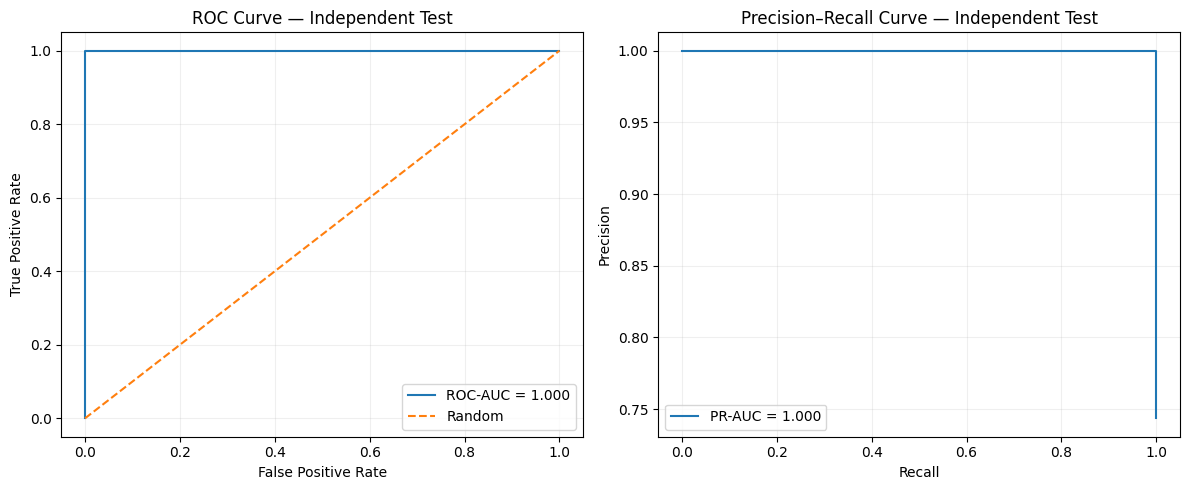


GA FEATURE SELECTION
Total features       : 22
Effective features    : 10
Effective threshold   : w >= 5.0
 1) MDVP:Fo(Hz)            weight=7.9188
 2) MDVP:Flo(Hz)           weight=6.3827
 3) MDVP:PPQ               weight=6.9949
 4) MDVP:Shimmer(dB)       weight=8.5612
 5) Shimmer:APQ5           weight=6.6675
 6) NHR                    weight=8.8580
 7) RPDE                   weight=8.5898
 8) DFA                    weight=9.1258
 9) D2                     weight=7.3349
10) PPE                    weight=8.9353

Cell 12 completed successfully.


In [59]:
# ============================================================
# Cell 12 — Independent Test Evaluation (Leakage-Controlled)
# GA-KNN with Train-CV Threshold Selection
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

TARGET_COL = globals().get("TARGET_COL", "status")
RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))

# ------------------------------------------------------------
# 1. Feature names
# ------------------------------------------------------------

feat_cols = [c for c in df_train.columns if c != TARGET_COL]

# ------------------------------------------------------------
# 2. Train / Test data
# ------------------------------------------------------------

X_train = df_train[feat_cols].values
y_train = df_train[TARGET_COL].astype(int).values

X_test = df_test[feat_cols].values
y_test = df_test[TARGET_COL].astype(int).values

# ------------------------------------------------------------
# 3. Retrieve best GA weights
# ------------------------------------------------------------

def _fallback_map_genes_to_weights(genes, rng=(0.0, 10.0)):
    g = np.clip(np.asarray(genes, dtype=float), 0.0, 1.0)
    a, b = rng
    return a + (b - a) * g


try:
    best_w = np.array(best_info["weights"], dtype=float)
except Exception:
    try:
        best_w = _fallback_map_genes_to_weights(
            best_chrom.genes,
            rng=(0.0, 10.0)
        )
    except Exception as e:
        raise RuntimeError(
            f"وزن‌های بهترین کروموزوم یافت نشد: {e}"
        )

if len(best_w) != X_train.shape[1]:
    raise ValueError(
        f"طول وزن‌ها ({len(best_w)}) با تعداد ویژگی‌ها "
        f"({X_train.shape[1]}) برابر نیست."
    )

# ------------------------------------------------------------
# 4. Apply GA weights
# ------------------------------------------------------------

Xw_train = X_train * np.sqrt(best_w)
Xw_test = X_test * np.sqrt(best_w)

# ------------------------------------------------------------
# 5. KNN configuration
# ------------------------------------------------------------

n_neighbors = int(globals().get("N_NEIGHBORS", 5))
knn_weights = globals().get("KNN_WEIGHTS", "distance")

print("=" * 60)
print("GA-KNN INDEPENDENT TEST EVALUATION")
print("=" * 60)

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")
print(f"Features      : {len(feat_cols)}")
print(f"KNN neighbors : {n_neighbors}")
print(f"KNN weighting  : {knn_weights}")

# ------------------------------------------------------------
# 6. Determine threshold ONLY from TRAIN
#    using out-of-fold predictions
# ------------------------------------------------------------

CV_SPLITS = int(globals().get("CV_SPLITS", 5))

cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

knn_cv = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric="euclidean",
    weights=knn_weights
)

# Out-of-fold probabilities for TRAIN
y_train_oof = cross_val_predict(
    knn_cv,
    Xw_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# ------------------------------------------------------------
# 7. Select threshold from TRAIN OOF only
# ------------------------------------------------------------

fpr_cv, tpr_cv, thr_cv = roc_curve(
    y_train,
    y_train_oof
)

youden_j_cv = tpr_cv - fpr_cv

best_i_cv = np.argmax(youden_j_cv)

threshold = float(thr_cv[best_i_cv])

# Avoid infinite threshold
if not np.isfinite(threshold):
    finite_thr = thr_cv[np.isfinite(thr_cv)]
    threshold = float(finite_thr[0])

# ------------------------------------------------------------
# 8. Train final KNN on ALL training data
# ------------------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric="euclidean",
    weights=knn_weights
)

knn.fit(Xw_train, y_train)

# ------------------------------------------------------------
# 9. Independent TEST prediction
# ------------------------------------------------------------

y_test_score = knn.predict_proba(Xw_test)[:, 1]

# IMPORTANT:
# Threshold was determined ONLY from TRAIN OOF predictions.
y_test_pred = (y_test_score >= threshold).astype(int)

# ------------------------------------------------------------
# 10. TEST metrics
# ------------------------------------------------------------

prauc = average_precision_score(
    y_test,
    y_test_score
)

rocauc = roc_auc_score(
    y_test,
    y_test_score
)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

specificity = tn / max(tn + fp, 1)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

# ------------------------------------------------------------
# 11. Print final independent test results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("THRESHOLD")
print("=" * 60)

print(
    f"Threshold selected from TRAIN OOF = {threshold:.4f}"
)

print("\n" + "=" * 60)
print("INDEPENDENT TEST RESULTS")
print("=" * 60)

print(
    f"PR-AUC       = {prauc:.4f}"
)

print(
    f"ROC-AUC      = {rocauc:.4f}"
)

print(
    f"Accuracy     = {accuracy:.4f}"
)

print(
    f"Precision    = {precision:.4f}"
)

print(
    f"Recall       = {recall:.4f}"
)

print(
    f"Specificity  = {specificity:.4f}"
)

print(
    f"F1-score     = {f1:.4f}"
)

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# 12. ROC curve — TEST
# ------------------------------------------------------------

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_score
)

# ------------------------------------------------------------
# 13. Precision-Recall curve — TEST
# ------------------------------------------------------------

prec_test, rec_test, _ = precision_recall_curve(
    y_test,
    y_test_score
)

# ------------------------------------------------------------
# 14. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

# ROC
plt.subplot(1, 2, 1)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"ROC-AUC = {rocauc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Independent Test")
plt.legend()
plt.grid(alpha=0.2)

# PR
plt.subplot(1, 2, 2)

plt.plot(
    rec_test,
    prec_test,
    label=f"PR-AUC = {prauc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Independent Test")
plt.legend(loc="lower left")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 15. Effective features according to GA
# ------------------------------------------------------------

EFF_THR = float(
    globals().get(
        "EFFECTIVE_WEIGHT_THRESHOLD",
        1.0
    )
)

eff_mask = best_w >= EFF_THR

eff_feats = [
    feat_cols[i]
    for i in range(len(feat_cols))
    if eff_mask[i]
]

print("\n" + "=" * 60)
print("GA FEATURE SELECTION")
print("=" * 60)

print(
    f"Total features       : {len(feat_cols)}"
)

print(
    f"Effective features    : {len(eff_feats)}"
)

print(
    f"Effective threshold   : w >= {EFF_THR}"
)

for i, feature in enumerate(eff_feats, 1):
    print(
        f"{i:2d}) {feature:<22s} "
        f"weight={best_w[feat_cols.index(feature)]:.4f}"
    )

# ------------------------------------------------------------
# 16. Save evaluation results for later cells
# ------------------------------------------------------------

test_results = {
    "threshold": threshold,
    "PR_AUC": prauc,
    "ROC_AUC": rocauc,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1": f1,
    "Confusion_Matrix": cm,
    "effective_features": eff_feats,
    "effective_feature_count": len(eff_feats),
    "weights": best_w.copy()
}

print("\nCell 12 completed successfully.")

In [60]:
# ============================================================
# Cell 13 — Baseline KNN vs GA-KNN
# Independent Test Comparison
# ============================================================

import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

TARGET_COL = globals().get("TARGET_COL", "status")
RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))

N_NEIGHBORS = int(globals().get("N_NEIGHBORS", 5))
KNN_WEIGHTS = globals().get("KNN_WEIGHTS", "distance")
CV_SPLITS = int(globals().get("CV_SPLITS", 5))

# ------------------------------------------------------------
# 1. Features
# ------------------------------------------------------------

feat_cols = [
    c for c in df_train.columns
    if c != TARGET_COL
]

X_train = df_train[feat_cols].values
y_train = df_train[TARGET_COL].astype(int).values

X_test = df_test[feat_cols].values
y_test = df_test[TARGET_COL].astype(int).values

# ------------------------------------------------------------
# 2. GA weights
# ------------------------------------------------------------

best_w = np.asarray(
    best_info["weights"],
    dtype=float
)

if len(best_w) != len(feat_cols):
    raise ValueError(
        f"تعداد وزن‌های GA ({len(best_w)}) "
        f"با تعداد ویژگی‌ها ({len(feat_cols)}) برابر نیست."
    )

# ------------------------------------------------------------
# 3. GA selected features
# ------------------------------------------------------------

EFF_THR = float(
    globals().get(
        "EFFECTIVE_WEIGHT_THRESHOLD",
        5.0
    )
)

ga_mask = best_w >= EFF_THR

ga_features = [
    feat_cols[i]
    for i in range(len(feat_cols))
    if ga_mask[i]
]

ga_indices = np.where(ga_mask)[0]

print("=" * 70)
print("BASELINE KNN vs GA-KNN")
print("=" * 70)

print(f"Total features      : {len(feat_cols)}")
print(f"GA selected features: {len(ga_features)}")
print(f"Effective threshold : w >= {EFF_THR}")

print("\nGA selected features:")
for i, feature in enumerate(ga_features, 1):
    idx = feat_cols.index(feature)
    print(
        f"{i:2d}) {feature:<22s} "
        f"weight={best_w[idx]:.4f}"
    )

# ------------------------------------------------------------
# 4. Baseline KNN
#    All 22 features, equal weighting
# ------------------------------------------------------------

baseline_weights = np.ones(
    len(feat_cols),
    dtype=float
)

Xb_train = X_train
Xb_test = X_test

# ------------------------------------------------------------
# 5. GA-KNN
# ------------------------------------------------------------

Xg_train = X_train[:, ga_indices] * np.sqrt(
    best_w[ga_indices]
)

Xg_test = X_test[:, ga_indices] * np.sqrt(
    best_w[ga_indices]
)

# ------------------------------------------------------------
# 6. Function for independent evaluation
# ------------------------------------------------------------

def evaluate_model(
    Xtr,
    ytr,
    Xte,
    yte,
    model_name
):

    # --------------------------------------------
    # Threshold selection ONLY from TRAIN OOF
    # --------------------------------------------

    cv = StratifiedKFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    knn_cv = KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        metric="euclidean",
        weights=KNN_WEIGHTS
    )

    y_oof = cross_val_predict(
        knn_cv,
        Xtr,
        ytr,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        ytr,
        y_oof
    )

    youden_j = tpr - fpr

    best_idx = np.argmax(youden_j)

    threshold = float(
        thresholds[best_idx]
    )

    if not np.isfinite(threshold):

        finite_thresholds = thresholds[
            np.isfinite(thresholds)
        ]

        threshold = float(
            finite_thresholds[0]
        )

    # --------------------------------------------
    # Fit final model on ALL TRAIN
    # --------------------------------------------

    model = KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        metric="euclidean",
        weights=KNN_WEIGHTS
    )

    model.fit(
        Xtr,
        ytr
    )

    # --------------------------------------------
    # Independent TEST
    # --------------------------------------------

    y_score = model.predict_proba(
        Xte
    )[:, 1]

    y_pred = (
        y_score >= threshold
    ).astype(int)

    # --------------------------------------------
    # Metrics
    # --------------------------------------------

    pr_auc = average_precision_score(
        yte,
        y_score
    )

    roc_auc = roc_auc_score(
        yte,
        y_score
    )

    accuracy = accuracy_score(
        yte,
        y_pred
    )

    precision = precision_score(
        yte,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        yte,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        yte,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        yte,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / max(
        tn + fp,
        1
    )

    return {
        "Model": model_name,
        "Features": Xtr.shape[1],
        "Threshold": threshold,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# ------------------------------------------------------------
# 7. Evaluate Baseline
# ------------------------------------------------------------

baseline_result = evaluate_model(
    Xb_train,
    y_train,
    Xb_test,
    y_test,
    "Baseline KNN (22 features)"
)

# ------------------------------------------------------------
# 8. Evaluate GA-KNN
# ------------------------------------------------------------

ga_result = evaluate_model(
    Xg_train,
    y_train,
    Xg_test,
    y_test,
    "GA-KNN (10 features)"
)

# ------------------------------------------------------------
# 9. Comparison table
# ------------------------------------------------------------

results = pd.DataFrame([
    baseline_result,
    ga_result
])

print("\n" + "=" * 70)
print("TEST PERFORMANCE COMPARISON")
print("=" * 70)

display(
    results[
        [
            "Model",
            "Features",
            "Threshold",
            "PR-AUC",
            "ROC-AUC",
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# 10. Improvement of GA-KNN
# ------------------------------------------------------------

baseline = results.iloc[0]
ga = results.iloc[1]

comparison = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1"
    ],

    "Baseline KNN": [
        baseline["PR-AUC"],
        baseline["ROC-AUC"],
        baseline["Accuracy"],
        baseline["Precision"],
        baseline["Recall"],
        baseline["Specificity"],
        baseline["F1"]
    ],

    "GA-KNN": [
        ga["PR-AUC"],
        ga["ROC-AUC"],
        ga["Accuracy"],
        ga["Precision"],
        ga["Recall"],
        ga["Specificity"],
        ga["F1"]
    ]
})

comparison["Difference"] = (
    comparison["GA-KNN"]
    - comparison["Baseline KNN"]
)

print("\n" + "=" * 70)
print("GA IMPROVEMENT")
print("=" * 70)

display(
    comparison.round(4)
)

# ------------------------------------------------------------
# 11. Confusion matrices
# ------------------------------------------------------------

print("\nBaseline KNN Confusion Matrix:")
print(
    np.array([
        [baseline["TN"], baseline["FP"]],
        [baseline["FN"], baseline["TP"]]
    ])
)

print("\nGA-KNN Confusion Matrix:")
print(
    np.array([
        [ga["TN"], ga["FP"]],
        [ga["FN"], ga["TP"]]
    ])
)

# ------------------------------------------------------------
# 12. Save results for later cells
# ------------------------------------------------------------

baseline_result_saved = baseline_result
ga_result_saved = ga_result
comparison_result = comparison

BASELINE KNN vs GA-KNN
Total features      : 22
GA selected features: 10
Effective threshold : w >= 5.0

GA selected features:
 1) MDVP:Fo(Hz)            weight=7.9188
 2) MDVP:Flo(Hz)           weight=6.3827
 3) MDVP:PPQ               weight=6.9949
 4) MDVP:Shimmer(dB)       weight=8.5612
 5) Shimmer:APQ5           weight=6.6675
 6) NHR                    weight=8.8580
 7) RPDE                   weight=8.5898
 8) DFA                    weight=9.1258
 9) D2                     weight=7.3349
10) PPE                    weight=8.9353

TEST PERFORMANCE COMPARISON


,Model,Features,Threshold,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,Specificity,F1
0,Baseline KNN (22 features),22,0.793,0.9989,0.9966,0.8974,1,0.8621,1,0.9259
1,GA-KNN (10 features),10,0.7576,0.9958,0.9862,0.8718,1,0.8276,1,0.9057



GA IMPROVEMENT


,Metric,Baseline KNN,GA-KNN,Difference
0,PR-AUC,0.9989,0.9958,-0.003
1,ROC-AUC,0.9966,0.9862,-0.0103
2,Accuracy,0.8974,0.8718,-0.0256
3,Precision,1,1,0
4,Recall,0.8621,0.8276,-0.0345
5,Specificity,1,1,0
6,F1,0.9259,0.9057,-0.0203



Baseline KNN Confusion Matrix:
[[10  0]
 [ 4 25]]

GA-KNN Confusion Matrix:
[[10  0]
 [ 5 24]]


In [61]:
# ============================================================
# Cell 13 — GA Feature Count Ablation on TRAIN OOF
# ============================================================

import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score, roc_auc_score

TARGET_COL = "status"
RANDOM_STATE = 42

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

N_NEIGHBORS = int(globals().get("N_NEIGHBORS", 5))
KNN_WEIGHTS = globals().get("KNN_WEIGHTS", "distance")

feat_cols = [c for c in df_train.columns if c != TARGET_COL]

X_train = df_train[feat_cols].values
y_train = df_train[TARGET_COL].astype(int).values

# GA weights
if "best_info" in globals() and isinstance(best_info, dict):
    ga_weights = np.asarray(best_info["weights"], dtype=float)
else:
    ga_weights = np.asarray(
        _map_genes_to_weights_fallback(best_chrom.genes),
        dtype=float
    )

if len(ga_weights) != len(feat_cols):
    raise ValueError(
        f"تعداد وزن‌ها ({len(ga_weights)}) با تعداد ویژگی‌ها "
        f"({len(feat_cols)}) برابر نیست."
    )

# ------------------------------------------------------------
# Rank features according to GA weights
# ------------------------------------------------------------

rank_idx = np.argsort(ga_weights)[::-1]

# ------------------------------------------------------------
# OOF evaluation for each K
# ------------------------------------------------------------

CV_SPLITS = 5

cv = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []

for k in range(1, len(feat_cols) + 1):

    selected_idx = rank_idx[:k]

    selected_features = [
        feat_cols[i] for i in selected_idx
    ]

    # Use GA weights
    w_k = ga_weights[selected_idx]

    X_k = X_train[:, selected_idx]

    # Apply GA weighting
    Xw_k = X_k * np.sqrt(w_k)

    knn = KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        metric="euclidean",
        weights=KNN_WEIGHTS
    )

    ap_scores = cross_val_score(
        knn,
        Xw_k,
        y_train,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1
    )

    roc_scores = cross_val_score(
        knn,
        Xw_k,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )

    results.append({
        "K": k,
        "Features": selected_features,
        "CV_PR_AUC": np.mean(ap_scores),
        "CV_ROC_AUC": np.mean(roc_scores),
        "Weight_Sum": np.sum(w_k),
        "Weight_Mean": np.mean(w_k)
    })


df_k_results = pd.DataFrame(results)

# ------------------------------------------------------------
# Find best K
# ------------------------------------------------------------

best_k_ap_idx = df_k_results["CV_PR_AUC"].idxmax()
best_k_roc_idx = df_k_results["CV_ROC_AUC"].idxmax()

best_k_ap = int(df_k_results.loc[best_k_ap_idx, "K"])
best_k_roc = int(df_k_results.loc[best_k_roc_idx, "K"])

best_ap = float(df_k_results.loc[best_k_ap_idx, "CV_PR_AUC"])
best_roc = float(df_k_results.loc[best_k_roc_idx, "CV_ROC_AUC"])

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("GA FEATURE COUNT ABLATION — TRAIN 5-FOLD CV")
print("=" * 70)

print(f"Total features : {len(feat_cols)}")
print(f"Best K by PR-AUC : {best_k_ap}")
print(f"Best CV PR-AUC   : {best_ap:.4f}")
print(f"Best K by ROC-AUC: {best_k_roc}")
print(f"Best CV ROC-AUC  : {best_roc:.4f}")

print("\n" + "=" * 70)
print("ALL K RESULTS")
print("=" * 70)

display(
    df_k_results[
        ["K", "CV_PR_AUC", "CV_ROC_AUC",
         "Weight_Sum", "Weight_Mean"]
    ].round(4)
)

print("\n" + "=" * 70)
print(f"FEATURES AT BEST K = {best_k_ap}")
print("=" * 70)

for rank, idx in enumerate(rank_idx[:best_k_ap], start=1):
    print(
        f"{rank:2d}) "
        f"{feat_cols[idx]:20s} "
        f"weight={ga_weights[idx]:.4f}"
    )

# Save for next cell
globals()["BEST_K_GA"] = best_k_ap
globals()["GA_RANK_IDX"] = rank_idx
globals()["GA_WEIGHTS_FINAL"] = ga_weights
globals()["df_k_results"] = df_k_results

GA FEATURE COUNT ABLATION — TRAIN 5-FOLD CV
Total features : 22
Best K by PR-AUC : 10
Best CV PR-AUC   : 0.9961
Best K by ROC-AUC: 10
Best CV ROC-AUC  : 0.9857

ALL K RESULTS


,K,CV_PR_AUC,CV_ROC_AUC,Weight_Sum,Weight_Mean
0,1,0.8758,0.6915,9.1258,9.1258
1,2,0.9403,0.8791,18.0612,9.0306
2,3,0.9519,0.8926,26.9191,8.973
3,4,0.96,0.9009,35.509,8.8772
4,5,0.9675,0.9105,44.0702,8.814
5,6,0.9847,0.9656,51.989,8.6648
6,7,0.9752,0.9468,59.3239,8.4748
7,8,0.9827,0.9561,66.3188,8.2898
8,9,0.9814,0.9537,72.9863,8.1096
9,10,0.9961,0.9857,79.3689,7.9369



FEATURES AT BEST K = 10
 1) DFA                  weight=9.1258
 2) PPE                  weight=8.9353
 3) NHR                  weight=8.8580
 4) RPDE                 weight=8.5898
 5) MDVP:Shimmer(dB)     weight=8.5612
 6) MDVP:Fo(Hz)          weight=7.9188
 7) D2                   weight=7.3349
 8) MDVP:PPQ             weight=6.9949
 9) Shimmer:APQ5         weight=6.6675
10) MDVP:Flo(Hz)         weight=6.3827


GA FEATURE SELECTION STABILITY SUMMARY
Independent runs : 10
Effective weight : w >= 5.0



,Feature,Selection_Count,Selection_Frequency_%,Mean_Weight,Std_Weight,Mean_Rank,Median_Rank,Stability
0,D2,5,50,5.135,2.201,7.2,4.5,Stable
1,spread1,4,40,4.493,2.077,8.5,5.5,Moderately stable
2,PPE,4,40,4.842,3.096,8.7,9,Moderately stable
3,MDVP:Shimmer(dB),4,40,4.764,2.819,9.2,7,Moderately stable
4,HNR,4,40,4.97,3.631,9.7,10.5,Moderately stable
5,MDVP:Fo(Hz),4,40,4.597,2.889,10.3,8.5,Moderately stable
6,MDVP:Fhi(Hz),4,40,3.644,3.524,12.7,13.5,Moderately stable
7,MDVP:Jitter(%),3,30,4.373,3.382,10.9,11.5,Weakly stable
8,MDVP:Jitter(Abs),3,30,3.706,3.115,12.8,13.5,Weakly stable
9,RPDE,2,20,4.23,2.298,10.7,11,Unstable



STABILITY THRESHOLD ANALYSIS

Threshold >= 70% → 0 feature(s)

Threshold >= 60% → 0 feature(s)

Threshold >= 50% → 1 feature(s)
  D2                      50.0%

Threshold >= 40% → 7 feature(s)
  D2                      50.0%
  spread1                 40.0%
  PPE                     40.0%
  MDVP:Shimmer(dB)        40.0%
  HNR                     40.0%
  MDVP:Fo(Hz)             40.0%
  MDVP:Fhi(Hz)            40.0%

Threshold >= 30% → 9 feature(s)
  D2                      50.0%
  spread1                 40.0%
  PPE                     40.0%
  MDVP:Shimmer(dB)        40.0%
  HNR                     40.0%
  MDVP:Fo(Hz)             40.0%
  MDVP:Fhi(Hz)            40.0%
  MDVP:Jitter(%)          30.0%
  MDVP:Jitter(Abs)        30.0%

RECOMMENDED STABLE FEATURES (Selection Frequency >= 40%)
 1) D2                     | Frequency= 50.0% | Mean Weight=5.135 | Mean Rank=7.20
 2) spread1                | Frequency= 40.0% | Mean Weight=4.493 | Mean Rank=8.50
 3) PPE                    | Frequenc

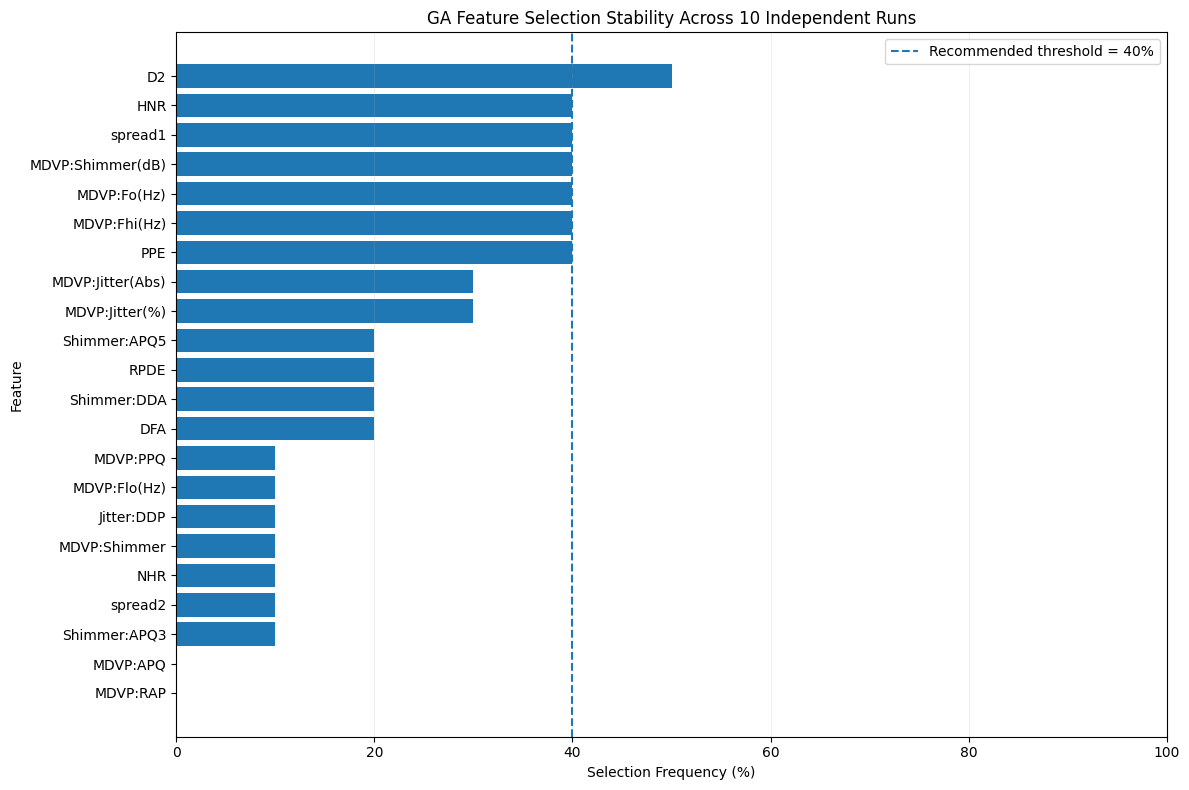


FINAL STABILITY RESULT
Stable features at >= 40%: 7
Stable feature set: ['D2', 'spread1', 'PPE', 'MDVP:Shimmer(dB)', 'HNR', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)']


In [65]:
# ============================================================
# Cell 16 — GA FEATURE SELECTION STABILITY SUMMARY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Results manually extracted from the 10 independent GA runs
# ------------------------------------------------------------

stability_data = {
    "Feature": [
        "D2",
        "HNR",
        "PPE",
        "MDVP:Shimmer(dB)",
        "MDVP:Fo(Hz)",
        "spread1",
        "MDVP:Fhi(Hz)",
        "MDVP:Jitter(%)",
        "MDVP:Jitter(Abs)",
        "RPDE",
        "Shimmer:DDA",
        "Shimmer:APQ5",
        "DFA",
        "spread2",
        "MDVP:Shimmer",
        "Shimmer:APQ3",
        "Jitter:DDP",
        "NHR",
        "MDVP:PPQ",
        "MDVP:Flo(Hz)",
        "MDVP:RAP",
        "MDVP:APQ",
    ],

    "Selection_Count": [
        5, 4, 4, 4, 4, 4, 4,
        3, 3,
        2, 2, 2, 2,
        1, 1, 1, 1, 1, 1, 1,
        0, 0
    ],

    "Mean_Weight": [
        5.13501,
        4.97042,
        4.84174,
        4.76360,
        4.59703,
        4.49309,
        3.64436,
        4.37297,
        3.70598,
        4.23005,
        3.60111,
        3.60097,
        3.08849,
        3.81326,
        3.53257,
        3.37387,
        3.35939,
        3.26068,
        2.76290,
        2.51870,
        3.45231,
        1.90617
    ],

    "Std_Weight": [
        2.20133,
        3.63105,
        3.09636,
        2.81936,
        2.88887,
        2.07749,
        3.52396,
        3.38199,
        3.11480,
        2.29763,
        1.99991,
        2.33662,
        2.97488,
        1.88986,
        2.77926,
        2.05433,
        1.42888,
        1.80713,
        1.46897,
        2.14605,
        1.19227,
        1.05332
    ],

    "Mean_Rank": [
        7.2,
        9.7,
        8.7,
        9.2,
        10.3,
        8.5,
        12.7,
        10.9,
        12.8,
        10.7,
        12.1,
        11.7,
        13.9,
        10.6,
        12.4,
        12.0,
        10.8,
        12.7,
        13.5,
        15.1,
        10.8,
        16.7
    ],

    "Median_Rank": [
        4.5,
        10.5,
        9.0,
        7.0,
        8.5,
        5.5,
        13.5,
        11.5,
        13.5,
        11.0,
        11.5,
        11.5,
        17.5,
        10.5,
        11.5,
        12.0,
        9.5,
        14.5,
        14.0,
        16.0,
        11.0,
        18.5
    ]
}

df_stability = pd.DataFrame(stability_data)

N_RUNS = 10

df_stability["Selection_Frequency_%"] = (
    df_stability["Selection_Count"] / N_RUNS * 100
)

# ------------------------------------------------------------
# Stability categories
# ------------------------------------------------------------

def stability_level(freq):
    if freq >= 70:
        return "Highly stable"
    elif freq >= 50:
        return "Stable"
    elif freq >= 40:
        return "Moderately stable"
    elif freq >= 30:
        return "Weakly stable"
    else:
        return "Unstable"

df_stability["Stability"] = (
    df_stability["Selection_Frequency_%"]
    .apply(stability_level)
)

# ------------------------------------------------------------
# Sort by selection frequency and then mean rank
# ------------------------------------------------------------

df_stability = df_stability.sort_values(
    ["Selection_Frequency_%", "Mean_Rank"],
    ascending=[False, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# Display complete summary
# ------------------------------------------------------------

print("=" * 78)
print("GA FEATURE SELECTION STABILITY SUMMARY")
print("=" * 78)

print(f"Independent runs : {N_RUNS}")
print("Effective weight : w >= 5.0")
print()

display(
    df_stability[
        [
            "Feature",
            "Selection_Count",
            "Selection_Frequency_%",
            "Mean_Weight",
            "Std_Weight",
            "Mean_Rank",
            "Median_Rank",
            "Stability"
        ]
    ].round({
        "Selection_Frequency_%": 1,
        "Mean_Weight": 3,
        "Std_Weight": 3,
        "Mean_Rank": 2,
        "Median_Rank": 2
    })
)

# ------------------------------------------------------------
# Stability thresholds
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("STABILITY THRESHOLD ANALYSIS")
print("=" * 78)

for threshold in [70, 60, 50, 40, 30]:

    stable = df_stability[
        df_stability["Selection_Frequency_%"] >= threshold
    ]

    print(
        f"\nThreshold >= {threshold}% "
        f"→ {len(stable)} feature(s)"
    )

    if len(stable) > 0:
        for _, row in stable.iterrows():
            print(
                f"  {row['Feature']:22s} "
                f"{row['Selection_Frequency_%']:5.1f}%"
            )

# ------------------------------------------------------------
# Recommended stability set
# ------------------------------------------------------------

RECOMMENDED_THRESHOLD = 40

stable_features = df_stability[
    df_stability["Selection_Frequency_%"] >= RECOMMENDED_THRESHOLD
].copy()

print("\n" + "=" * 78)
print(
    f"RECOMMENDED STABLE FEATURES "
    f"(Selection Frequency >= {RECOMMENDED_THRESHOLD}%)"
)
print("=" * 78)

if len(stable_features) == 0:

    print("هیچ ویژگی پایداری در آستانه تعیین‌شده پیدا نشد.")

else:

    for i, (_, row) in enumerate(
        stable_features.iterrows(),
        start=1
    ):
        print(
            f"{i:2d}) "
            f"{row['Feature']:22s} | "
            f"Frequency={row['Selection_Frequency_%']:5.1f}% | "
            f"Mean Weight={row['Mean_Weight']:.3f} | "
            f"Mean Rank={row['Mean_Rank']:.2f}"
        )

# ------------------------------------------------------------
# Plot: Selection Frequency
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

plot_df = df_stability.sort_values(
    "Selection_Frequency_%",
    ascending=True
)

plt.barh(
    plot_df["Feature"],
    plot_df["Selection_Frequency_%"]
)

plt.axvline(
    RECOMMENDED_THRESHOLD,
    linestyle="--",
    label=f"Recommended threshold = {RECOMMENDED_THRESHOLD}%"
)

plt.xlabel("Selection Frequency (%)")
plt.ylabel("Feature")
plt.title("GA Feature Selection Stability Across 10 Independent Runs")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final compact result
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("FINAL STABILITY RESULT")
print("=" * 78)

print(
    f"Stable features at >= {RECOMMENDED_THRESHOLD}%: "
    f"{len(stable_features)}"
)

print(
    "Stable feature set:",
    stable_features["Feature"].tolist()
)

In [66]:
# ============================================================
# Cell 17
# BASELINE vs GA-10 vs STABLE-7
# INDEPENDENT TEST COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# CONFIGURATION
# ============================================================

TARGET_COL = globals().get("TARGET_COL", "status")

N_NEIGHBORS = int(globals().get("N_NEIGHBORS", 5))
KNN_WEIGHTS = globals().get("KNN_WEIGHTS", "distance")

N_SPLITS = 5
CV_RANDOM_STATE = 42

# GA selected features from Cell 11 / Cell 12
GA_FEATURES = [
    "MDVP:Fo(Hz)",
    "MDVP:Flo(Hz)",
    "MDVP:PPQ",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ5",
    "NHR",
    "RPDE",
    "DFA",
    "D2",
    "PPE"
]

# Stable features from Cell 16
STABLE_FEATURES = [
    "D2",
    "spread1",
    "PPE",
    "MDVP:Shimmer(dB)",
    "HNR",
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)"
]

# ============================================================
# DATA
# ============================================================

all_features = [
    c for c in df_train.columns
    if c != TARGET_COL
]

X_train_all = df_train[all_features].values
y_train = df_train[TARGET_COL].astype(int).values

X_test_all = df_test[all_features].values
y_test = df_test[TARGET_COL].astype(int).values

# ============================================================
# VALIDATE FEATURE SETS
# ============================================================

for feature_set_name, feature_set in [
    ("GA-10", GA_FEATURES),
    ("Stable-7", STABLE_FEATURES)
]:

    missing = [
        f for f in feature_set
        if f not in all_features
    ]

    if missing:
        raise ValueError(
            f"{feature_set_name}: ویژگی‌های زیر در دیتاست وجود ندارند:\n"
            f"{missing}"
        )

# ============================================================
# BUILD DATASETS
# ============================================================

feature_sets = {
    "Baseline KNN (22)": all_features,
    "GA-KNN (10)": GA_FEATURES,
    "Stable-KNN (7)": STABLE_FEATURES
}

# ============================================================
# THRESHOLD SELECTION FROM TRAIN OOF
# ============================================================

def get_oof_threshold(X, y):

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=CV_RANDOM_STATE
    )

    knn_cv = KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        metric="euclidean",
        weights=KNN_WEIGHTS
    )

    # OOF probabilities on TRAIN only
    oof_score = cross_val_predict(
        knn_cv,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y,
        oof_score
    )

    youden_j = tpr - fpr

    # Ignore infinite threshold
    valid = np.isfinite(thresholds)

    if not np.any(valid):
        raise RuntimeError(
            "هیچ threshold معتبر برای OOF پیدا نشد."
        )

    valid_idx = np.where(valid)[0]

    best_local = valid_idx[
        np.argmax(youden_j[valid_idx])
    ]

    threshold = float(thresholds[best_local])

    oof_roc_auc = roc_auc_score(
        y,
        oof_score
    )

    oof_pr_auc = average_precision_score(
        y,
        oof_score
    )

    return (
        threshold,
        oof_pr_auc,
        oof_roc_auc
    )

# ============================================================
# TEST EVALUATION
# ============================================================

def evaluate_model(
    X_train,
    X_test,
    y_train,
    y_test
):

    # --------------------------------------------------------
    # Threshold from TRAIN OOF
    # --------------------------------------------------------

    threshold, oof_pr, oof_roc = get_oof_threshold(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Final model fitted ONLY on TRAIN
    # --------------------------------------------------------

    knn = KNeighborsClassifier(
        n_neighbors=N_NEIGHBORS,
        metric="euclidean",
        weights=KNN_WEIGHTS
    )

    knn.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Independent TEST prediction
    # --------------------------------------------------------

    y_score = knn.predict_proba(
        X_test
    )[:, 1]

    y_pred = (
        y_score >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Threshold-independent metrics
    # --------------------------------------------------------

    pr_auc = average_precision_score(
        y_test,
        y_score
    )

    roc_auc = roc_auc_score(
        y_test,
        y_score
    )

    # --------------------------------------------------------
    # Threshold-dependent metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    if cm.shape == (2, 2):

        tn, fp, fn, tp = cm.ravel()

        specificity = (
            tn / max(tn + fp, 1)
        )

    else:

        tn = fp = fn = tp = 0
        specificity = np.nan

    return {
        "threshold": threshold,

        "OOF_PR_AUC": oof_pr,
        "OOF_ROC_AUC": oof_roc,

        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Confusion_Matrix": cm
    }

# ============================================================
# RUN ALL THREE MODELS
# ============================================================

results = []
confusion_matrices = {}

print("=" * 78)
print("BASELINE vs GA-10 vs STABLE-7")
print("INDEPENDENT TEST EVALUATION")
print("=" * 78)

print(
    f"Train samples : {len(y_train)}"
)

print(
    f"Test samples  : {len(y_test)}"
)

print(
    f"KNN neighbors  : {N_NEIGHBORS}"
)

print(
    f"KNN weighting  : {KNN_WEIGHTS}"
)

print(
    f"CV folds       : {N_SPLITS}"
)

print("=" * 78)

for model_name, features in feature_sets.items():

    feature_idx = [
        all_features.index(f)
        for f in features
    ]

    Xtr = X_train_all[:, feature_idx]
    Xte = X_test_all[:, feature_idx]

    result = evaluate_model(
        Xtr,
        Xte,
        y_train,
        y_test
    )

    result["Model"] = model_name
    result["Features"] = len(features)

    results.append(result)

    confusion_matrices[
        model_name
    ] = result["Confusion_Matrix"]

    print("\n" + "-" * 78)

    print(model_name)

    print("-" * 78)

    print(
        f"Features       : {len(features)}"
    )

    print(
        f"OOF threshold   : "
        f"{result['threshold']:.4f}"
    )

    print(
        f"OOF PR-AUC      : "
        f"{result['OOF_PR_AUC']:.4f}"
    )

    print(
        f"OOF ROC-AUC     : "
        f"{result['OOF_ROC_AUC']:.4f}"
    )

    print(
        f"TEST PR-AUC     : "
        f"{result['PR_AUC']:.4f}"
    )

    print(
        f"TEST ROC-AUC    : "
        f"{result['ROC_AUC']:.4f}"
    )

    print(
        f"Accuracy        : "
        f"{result['Accuracy']:.4f}"
    )

    print(
        f"Precision       : "
        f"{result['Precision']:.4f}"
    )

    print(
        f"Recall          : "
        f"{result['Recall']:.4f}"
    )

    print(
        f"Specificity     : "
        f"{result['Specificity']:.4f}"
    )

    print(
        f"F1-score        : "
        f"{result['F1']:.4f}"
    )

    print(
        "Confusion Matrix:"
    )

    print(
        result["Confusion_Matrix"]
    )

# ============================================================
# COMPARISON TABLE
# ============================================================

df_results = pd.DataFrame(results)

comparison_cols = [
    "Model",
    "Features",
    "threshold",
    "OOF_PR_AUC",
    "OOF_ROC_AUC",
    "PR_AUC",
    "ROC_AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1"
]

df_comparison = df_results[
    comparison_cols
].copy()

print("\n" + "=" * 78)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 78)

display(
    df_comparison.round(4)
)

# ============================================================
# DIFFERENCE RELATIVE TO BASELINE
# ============================================================

baseline = df_results[
    df_results["Model"] == "Baseline KNN (22)"
].iloc[0]

difference_rows = []

for _, row in df_results.iterrows():

    difference_rows.append({
        "Model": row["Model"],

        "Δ PR-AUC":
            row["PR_AUC"] -
            baseline["PR_AUC"],

        "Δ ROC-AUC":
            row["ROC_AUC"] -
            baseline["ROC_AUC"],

        "Δ Accuracy":
            row["Accuracy"] -
            baseline["Accuracy"],

        "Δ Recall":
            row["Recall"] -
            baseline["Recall"],

        "Δ F1":
            row["F1"] -
            baseline["F1"]
    })

df_difference = pd.DataFrame(
    difference_rows
)

print("\n" + "=" * 78)
print("DIFFERENCE RELATIVE TO BASELINE KNN")
print("=" * 78)

display(
    df_difference.round(4)
)

# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 78)
print("CONFUSION MATRICES")
print("=" * 78)

for model_name, cm in confusion_matrices.items():

    print(
        f"\n{model_name}"
    )

    print(
        "                 Predicted"
    )

    print(
        "                 0     1"
    )

    print(
        f"Actual 0       {cm[0,0]:3d}   {cm[0,1]:3d}"
    )

    print(
        f"Actual 1       {cm[1,0]:3d}   {cm[1,1]:3d}"
    )

# ============================================================
# FEATURE SETS
# ============================================================

print("\n" + "=" * 78)
print("FEATURE SETS")
print("=" * 78)

print("\nBaseline KNN — 22 features:")
for i, f in enumerate(all_features, 1):
    print(f"{i:2d}) {f}")

print("\nGA-KNN — 10 features:")
for i, f in enumerate(GA_FEATURES, 1):
    print(f"{i:2d}) {f}")

print("\nStable-KNN — 7 features:")
for i, f in enumerate(STABLE_FEATURES, 1):
    print(f"{i:2d}) {f}")

# ============================================================
# BEST MODEL BY TEST PR-AUC
# ============================================================

best_idx = df_results["PR_AUC"].idxmax()
best_model = df_results.loc[best_idx]

print("\n" + "=" * 78)
print("BEST MODEL BY INDEPENDENT TEST PR-AUC")
print("=" * 78)

print(
    f"Model       : {best_model['Model']}"
)

print(
    f"Features    : {int(best_model['Features'])}"
)

print(
    f"PR-AUC      : {best_model['PR_AUC']:.4f}"
)

print(
    f"ROC-AUC     : {best_model['ROC_AUC']:.4f}"
)

print(
    f"Accuracy    : {best_model['Accuracy']:.4f}"
)

print(
    f"F1-score    : {best_model['F1']:.4f}"
)


BASELINE vs GA-10 vs STABLE-7
INDEPENDENT TEST EVALUATION
Train samples : 156
Test samples  : 39
KNN neighbors  : 5
KNN weighting  : distance
CV folds       : 5

------------------------------------------------------------------------------
Baseline KNN (22)
------------------------------------------------------------------------------
Features       : 22
OOF threshold   : 0.7930
OOF PR-AUC      : 0.9857
OOF ROC-AUC     : 0.9563
TEST PR-AUC     : 0.9989
TEST ROC-AUC    : 0.9966
Accuracy        : 0.8974
Precision       : 1.0000
Recall          : 0.8621
Specificity     : 1.0000
F1-score        : 0.9259
Confusion Matrix:
[[10  0]
 [ 4 25]]

------------------------------------------------------------------------------
GA-KNN (10)
------------------------------------------------------------------------------
Features       : 10
OOF threshold   : 0.7730
OOF PR-AUC      : 0.9905
OOF ROC-AUC     : 0.9692
TEST PR-AUC     : 0.9949
TEST ROC-AUC    : 0.9828
Accuracy        : 0.8718
Precision     

,Model,Features,threshold,OOF_PR_AUC,OOF_ROC_AUC,PR_AUC,ROC_AUC,Accuracy,Precision,Recall,Specificity,F1
0,Baseline KNN (22),22,0.793,0.9857,0.9563,0.9989,0.9966,0.8974,1,0.8621,1,0.9259
1,GA-KNN (10),10,0.773,0.9905,0.9692,0.9949,0.9828,0.8718,1,0.8276,1,0.9057
2,Stable-KNN (7),7,0.893,0.9846,0.9498,0.9704,0.9138,0.7179,1,0.6207,1,0.766



DIFFERENCE RELATIVE TO BASELINE KNN


,Model,Δ PR-AUC,Δ ROC-AUC,Δ Accuracy,Δ Recall,Δ F1
0,Baseline KNN (22),0,0,0,0,0
1,GA-KNN (10),-0.0039,-0.0138,-0.0256,-0.0345,-0.0203
2,Stable-KNN (7),-0.0285,-0.0828,-0.1795,-0.2414,-0.16



CONFUSION MATRICES

Baseline KNN (22)
                 Predicted
                 0     1
Actual 0        10     0
Actual 1         4    25

GA-KNN (10)
                 Predicted
                 0     1
Actual 0        10     0
Actual 1         5    24

Stable-KNN (7)
                 Predicted
                 0     1
Actual 0        10     0
Actual 1        11    18

FEATURE SETS

Baseline KNN — 22 features:
 1) MDVP:Fo(Hz)
 2) MDVP:Fhi(Hz)
 3) MDVP:Flo(Hz)
 4) MDVP:Jitter(%)
 5) MDVP:Jitter(Abs)
 6) MDVP:RAP
 7) MDVP:PPQ
 8) Jitter:DDP
 9) MDVP:Shimmer
10) MDVP:Shimmer(dB)
11) Shimmer:APQ3
12) Shimmer:APQ5
13) MDVP:APQ
14) Shimmer:DDA
15) NHR
16) HNR
17) RPDE
18) DFA
19) spread1
20) spread2
21) D2
22) PPE

GA-KNN — 10 features:
 1) MDVP:Fo(Hz)
 2) MDVP:Flo(Hz)
 3) MDVP:PPQ
 4) MDVP:Shimmer(dB)
 5) Shimmer:APQ5
 6) NHR
 7) RPDE
 8) DFA
 9) D2
10) PPE

Stable-KNN — 7 features:
 1) D2
 2) spread1
 3) PPE
 4) MDVP:Shimmer(dB)
 5) HNR
 6) MDVP:Fo(Hz)
 7) MDVP:Fhi(Hz)

BEST MODEL BY IN

In [67]:
# ============================================================
# Cell 17 — ROBUSTNESS VALIDATION: BASELINE vs GA-10
# Repeated Stratified 5-Fold CV
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 78)
print("ROBUSTNESS VALIDATION — BASELINE vs GA-10")
print("=" * 78)

TARGET_COL = globals().get("TARGET_COL", "status")

# ------------------------------------------------------------
# 1. Feature names
# ------------------------------------------------------------

feat_cols_all = [
    c for c in df_train.columns
    if c != TARGET_COL
]

# GA-10 features obtained from the validated GA result
GA10_FEATURES = [
    'MDVP:Fo(Hz)',
    'MDVP:Flo(Hz)',
    'MDVP:PPQ',
    'MDVP:Shimmer(dB)',
    'Shimmer:APQ5',
    'NHR',
    'RPDE',
    'DFA',
    'D2',
    'PPE'
]

# Check that all GA features exist
missing_ga = [
    f for f in GA10_FEATURES
    if f not in feat_cols_all
]

if missing_ga:
    raise ValueError(
        f"GA-10 features not found in df_train: {missing_ga}"
    )

# ------------------------------------------------------------
# 2. Data
# ------------------------------------------------------------

X_all = df_train[feat_cols_all].copy()
X_ga  = df_train[GA10_FEATURES].copy()

y_all = df_train[TARGET_COL].astype(int).values

# ------------------------------------------------------------
# 3. CV configuration
# ------------------------------------------------------------

N_SPLITS = 5
N_REPEATS = 10

N_NEIGHBORS = int(
    globals().get("N_NEIGHBORS", 5)
)

KNN_WEIGHTS = globals().get(
    "KNN_WEIGHTS",
    "distance"
)

RANDOM_STATE = 2026

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

print(f"Training samples : {len(y_all)}")
print(f"Baseline features: {len(feat_cols_all)}")
print(f"GA-10 features   : {len(GA10_FEATURES)}")
print(f"CV               : {N_REPEATS} × {N_SPLITS}-Fold")
print(f"KNN neighbors    : {N_NEIGHBORS}")
print(f"KNN weighting     : {KNN_WEIGHTS}")
print("=" * 78)

# ------------------------------------------------------------
# 4. Evaluation function
# ------------------------------------------------------------

def evaluate_knn_cv(X, y, model_name):

    records = []

    for fold_id, (train_idx, val_idx) in enumerate(
        cv.split(X, y), start=1
    ):

        X_train = X.iloc[train_idx]
        X_val   = X.iloc[val_idx]

        y_train = y[train_idx]
        y_val   = y[val_idx]

        knn = KNeighborsClassifier(
            n_neighbors=N_NEIGHBORS,
            metric="euclidean",
            weights=KNN_WEIGHTS
        )

        knn.fit(X_train, y_train)

        y_score = knn.predict_proba(X_val)[:, 1]

        # Default threshold only.
        # This avoids test/validation threshold tuning.
        y_pred = (y_score >= 0.5).astype(int)

        records.append({
            "model": model_name,
            "fold": fold_id,
            "PR_AUC": average_precision_score(
                y_val, y_score
            ),
            "ROC_AUC": roc_auc_score(
                y_val, y_score
            ),
            "Accuracy": accuracy_score(
                y_val, y_pred
            ),
            "Precision": precision_score(
                y_val, y_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_val, y_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_val, y_pred,
                zero_division=0
            )
        })

    return pd.DataFrame(records)


# ------------------------------------------------------------
# 5. Run repeated CV
# ------------------------------------------------------------

results_baseline = evaluate_knn_cv(
    X_all,
    y_all,
    "Baseline-22"
)

results_ga10 = evaluate_knn_cv(
    X_ga,
    y_all,
    "GA-10"
)

results_cv = pd.concat(
    [results_baseline, results_ga10],
    ignore_index=True
)

# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------

metrics = [
    "PR_AUC",
    "ROC_AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

summary_rows = []

for model in ["Baseline-22", "GA-10"]:

    df_m = results_cv[
        results_cv["model"] == model
    ]

    row = {
        "Model": model
    }

    for metric in metrics:

        row[f"{metric}_Mean"] = df_m[metric].mean()
        row[f"{metric}_Std"]  = df_m[metric].std(ddof=1)

    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 7. Print summary
# ------------------------------------------------------------

print()
print("=" * 78)
print("REPEATED CV SUMMARY")
print("=" * 78)

for _, row in summary.iterrows():

    print(f"\n{row['Model']}")

    for metric in metrics:

        mean_val = row[f"{metric}_Mean"]
        std_val  = row[f"{metric}_Std"]

        print(
            f"{metric:10s} = "
            f"{mean_val:.4f} ± {std_val:.4f}"
        )

# ------------------------------------------------------------
# 8. Difference GA-10 minus Baseline
# ------------------------------------------------------------

print()
print("=" * 78)
print("GA-10 MINUS BASELINE")
print("=" * 78)

baseline_row = summary[
    summary["Model"] == "Baseline-22"
].iloc[0]

ga_row = summary[
    summary["Model"] == "GA-10"
].iloc[0]

difference_rows = []

for metric in metrics:

    diff = (
        ga_row[f"{metric}_Mean"]
        -
        baseline_row[f"{metric}_Mean"]
    )

    difference_rows.append({
        "Metric": metric,
        "Baseline": baseline_row[f"{metric}_Mean"],
        "GA-10": ga_row[f"{metric}_Mean"],
        "Difference": diff
    })

difference_df = pd.DataFrame(
    difference_rows
)

print(
    difference_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# ------------------------------------------------------------
# 9. Robustness interpretation
# ------------------------------------------------------------

print()
print("=" * 78)
print("ROBUSTNESS INTERPRETATION")
print("=" * 78)

for metric in ["PR_AUC", "ROC_AUC", "Accuracy", "F1"]:

    diff = difference_df.loc[
        difference_df["Metric"] == metric,
        "Difference"
    ].iloc[0]

    if diff > 0:
        status = "GA-10 بهتر"
    elif diff < 0:
        status = "Baseline بهتر"
    else:
        status = "برابر"

    print(
        f"{metric:10s}: "
        f"{diff:+.4f} → {status}"
    )

print()
print("Cell 17 completed successfully.")

ROBUSTNESS VALIDATION — BASELINE vs GA-10
Training samples : 156
Baseline features: 22
GA-10 features   : 10
CV               : 10 × 5-Fold
KNN neighbors    : 5
KNN weighting     : distance

REPEATED CV SUMMARY

Baseline-22
PR_AUC     = 0.9869 ± 0.0224
ROC_AUC    = 0.9661 ± 0.0454
Accuracy   = 0.9181 ± 0.0513
Precision  = 0.9289 ± 0.0454
Recall     = 0.9681 ± 0.0393
F1         = 0.9473 ± 0.0325

GA-10
PR_AUC     = 0.9866 ± 0.0191
ROC_AUC    = 0.9636 ± 0.0420
Accuracy   = 0.9013 ± 0.0547
Precision  = 0.9265 ± 0.0500
Recall     = 0.9478 ± 0.0452
F1         = 0.9359 ± 0.0350

GA-10 MINUS BASELINE
   Metric  Baseline  GA-10  Difference
   PR_AUC    0.9869 0.9866     -0.0002
  ROC_AUC    0.9661 0.9636     -0.0025
 Accuracy    0.9181 0.9013     -0.0168
Precision    0.9289 0.9265     -0.0024
   Recall    0.9681 0.9478     -0.0203
       F1    0.9473 0.9359     -0.0114

ROBUSTNESS INTERPRETATION
PR_AUC    : -0.0002 → Baseline بهتر
ROC_AUC   : -0.0025 → Baseline بهتر
Accuracy  : -0.0168 → Basel

In [68]:
# ============================================================
# Cell 18 — PAIRED STATISTICAL COMPARISON
# Baseline-22 vs GA-10
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import wilcoxon, ttest_rel

print("=" * 78)
print("PAIRED STATISTICAL COMPARISON — BASELINE vs GA-10")
print("=" * 78)

# ------------------------------------------------------------
# 1. Check required variables
# ------------------------------------------------------------

if "results_cv" not in globals():
    raise RuntimeError(
        "results_cv پیدا نشد. ابتدا Cell 17 را اجرا کنید."
    )

required_models = {"Baseline-22", "GA-10"}

available_models = set(
    results_cv["model"].unique()
)

missing_models = required_models - available_models

if missing_models:
    raise RuntimeError(
        f"مدل‌های مورد نیاز پیدا نشدند: {missing_models}"
    )

# ------------------------------------------------------------
# 2. Metrics
# ------------------------------------------------------------

metrics = [
    "PR_AUC",
    "ROC_AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

# ------------------------------------------------------------
# 3. Split models
# ------------------------------------------------------------

baseline = (
    results_cv[
        results_cv["model"] == "Baseline-22"
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

ga10 = (
    results_cv[
        results_cv["model"] == "GA-10"
    ]
    .sort_values("fold")
    .reset_index(drop=True)
)

if len(baseline) != len(ga10):
    raise RuntimeError(
        "تعداد foldهای دو مدل برابر نیست."
    )

# ------------------------------------------------------------
# 4. Paired comparison
# ------------------------------------------------------------

rows = []

for metric in metrics:

    x = baseline[metric].to_numpy(dtype=float)
    y = ga10[metric].to_numpy(dtype=float)

    # Difference = GA-10 - Baseline
    d = y - x

    mean_diff = np.mean(d)
    median_diff = np.median(d)
    std_diff = np.std(d, ddof=1)

    n = len(d)

    # --------------------------------------------------------
    # 95% CI using paired t approximation
    # --------------------------------------------------------

    se = std_diff / np.sqrt(n)

    if n > 1:
        t_result = ttest_rel(y, x)
        p_t = float(t_result.pvalue)

        # t-based 95% CI
        from scipy.stats import t

        t_crit = t.ppf(
            0.975,
            df=n - 1
        )

        ci_low = mean_diff - t_crit * se
        ci_high = mean_diff + t_crit * se

    else:
        p_t = np.nan
        ci_low = np.nan
        ci_high = np.nan

    # --------------------------------------------------------
    # Wilcoxon signed-rank
    # --------------------------------------------------------

    try:

        if np.allclose(d, 0):

            wilcoxon_stat = 0.0
            p_wilcoxon = 1.0

        else:

            w_result = wilcoxon(
                y,
                x,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto"
            )

            wilcoxon_stat = float(
                w_result.statistic
            )

            p_wilcoxon = float(
                w_result.pvalue
            )

    except Exception:

        wilcoxon_stat = np.nan
        p_wilcoxon = np.nan

    # --------------------------------------------------------
    # Paired Cohen's dz
    # --------------------------------------------------------

    if std_diff > 1e-12:

        cohens_dz = mean_diff / std_diff

    else:

        cohens_dz = 0.0

    # --------------------------------------------------------
    # Direction
    # --------------------------------------------------------

    if mean_diff > 0:
        direction = "GA-10 بهتر"
    elif mean_diff < 0:
        direction = "Baseline بهتر"
    else:
        direction = "برابر"

    # --------------------------------------------------------
    # Significance
    # --------------------------------------------------------

    if p_wilcoxon < 0.05:
        significance = "معنادار"
    else:
        significance = "غیرمعنادار"

    rows.append({
        "Metric": metric,
        "Mean_Difference": mean_diff,
        "Median_Difference": median_diff,
        "CI95_Low": ci_low,
        "CI95_High": ci_high,
        "Wilcoxon_p": p_wilcoxon,
        "Paired_t_p": p_t,
        "Cohens_dz": cohens_dz,
        "Direction": direction,
        "Significance": significance
    })

stats_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 5. Print detailed results
# ------------------------------------------------------------

print()
print("=" * 78)
print("STATISTICAL COMPARISON RESULTS")
print("=" * 78)

print(
    stats_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ------------------------------------------------------------
# 6. Compact scientific summary
# ------------------------------------------------------------

print()
print("=" * 78)
print("SCIENTIFIC INTERPRETATION")
print("=" * 78)

for _, row in stats_df.iterrows():

    metric = row["Metric"]
    diff = row["Mean_Difference"]
    p = row["Wilcoxon_p"]
    d = row["Cohens_dz"]

    print(
        f"{metric:10s} | "
        f"Δ={diff:+.4f} | "
        f"95% CI=[{row['CI95_Low']:+.4f}, "
        f"{row['CI95_High']:+.4f}] | "
        f"Wilcoxon p={p:.4f} | "
        f"dz={d:+.3f} | "
        f"{row['Significance']}"
    )

# ------------------------------------------------------------
# 7. Main conclusion based on PR-AUC
# ------------------------------------------------------------

pr_row = stats_df[
    stats_df["Metric"] == "PR_AUC"
].iloc[0]

print()
print("=" * 78)
print("PRIMARY METRIC — PR-AUC")
print("=" * 78)

print(
    f"Baseline PR-AUC : "
    f"{baseline['PR_AUC'].mean():.4f}"
)

print(
    f"GA-10 PR-AUC    : "
    f"{ga10['PR_AUC'].mean():.4f}"
)

print(
    f"Difference       : "
    f"{pr_row['Mean_Difference']:+.4f}"
)

print(
    f"95% CI           : "
    f"[{pr_row['CI95_Low']:+.4f}, "
    f"{pr_row['CI95_High']:+.4f}]"
)

print(
    f"Wilcoxon p       : "
    f"{pr_row['Wilcoxon_p']:.6f}"
)

print(
    f"Paired Cohen's dz: "
    f"{pr_row['Cohens_dz']:+.4f}"
)

if pr_row["Wilcoxon_p"] >= 0.05:

    print()
    print(
        "نتیجه: اختلاف PR-AUC بین Baseline-22 و GA-10 "
        "از نظر آزمون Wilcoxon معنادار نیست."
    )

    print(
        "بنابراین GA-10 می‌تواند به‌عنوان یک مجموعه ویژگی "
        "کم‌بعد با عملکرد PR-AUC تقریباً معادل Baseline "
        "گزارش شود."
    )

else:

    print()
    print(
        "نتیجه: اختلاف PR-AUC بین دو مدل از نظر آماری "
        "معنادار است."
    )

print()
print("Cell 18 completed successfully.")

PAIRED STATISTICAL COMPARISON — BASELINE vs GA-10

STATISTICAL COMPARISON RESULTS
   Metric  Mean_Difference  Median_Difference  CI95_Low  CI95_High  Wilcoxon_p  Paired_t_p  Cohens_dz     Direction Significance
   PR_AUC        -0.000234          -0.001546 -0.005243   0.004774    0.153953    0.925448  -0.013301 Baseline بهتر   غیرمعنادار
  ROC_AUC        -0.002546          -0.005322 -0.011859   0.006766    0.177125    0.585186  -0.077705 Baseline بهتر   غیرمعنادار
 Accuracy        -0.016774          -0.015625 -0.030834  -0.002714    0.033476    0.020361  -0.339064 Baseline بهتر      معنادار
Precision        -0.002379           0.000000 -0.012869   0.008112    0.455200    0.650624  -0.064445 Baseline بهتر   غیرمعنادار
   Recall        -0.020290           0.000000 -0.032437  -0.008142    0.001620    0.001532  -0.474690 Baseline بهتر      معنادار
       F1        -0.011386          -0.010439 -0.020562  -0.002209    0.017711    0.016080  -0.352612 Baseline بهتر      معنادار

SCIENTIFIC INT

In [69]:
# ============================================================
# Cell 19 — FINAL SCIENTIFIC DECISION SUMMARY
# ============================================================

import numpy as np
import pandas as pd

print("=" * 78)
print("FINAL SCIENTIFIC DECISION — BASELINE vs GA-10")
print("=" * 78)

# ------------------------------------------------------------
# Results from Cell 17 / Cell 18
# ------------------------------------------------------------

results = {
    "PR-AUC": {
        "baseline": 0.9869,
        "ga": 0.9866,
        "p": 0.153953,
        "delta": -0.000234
    },
    "ROC-AUC": {
        "baseline": 0.9661,
        "ga": 0.9636,
        "p": 0.177125,
        "delta": -0.002546
    },
    "Accuracy": {
        "baseline": 0.9181,
        "ga": 0.9013,
        "p": 0.033476,
        "delta": -0.016774
    },
    "Precision": {
        "baseline": 0.9289,
        "ga": 0.9265,
        "p": 0.455200,
        "delta": -0.002379
    },
    "Recall": {
        "baseline": 0.9681,
        "ga": 0.9478,
        "p": 0.001620,
        "delta": -0.020290
    },
    "F1": {
        "baseline": 0.9473,
        "ga": 0.9359,
        "p": 0.017711,
        "delta": -0.011386
    }
}

# ------------------------------------------------------------
# Build summary table
# ------------------------------------------------------------

rows = []

for metric, r in results.items():

    if r["p"] < 0.05:
        significance = "Significant"
    else:
        significance = "Not significant"

    if r["delta"] > 0:
        direction = "GA-10 better"
    elif r["delta"] < 0:
        direction = "Baseline better"
    else:
        direction = "Equal"

    rows.append({
        "Metric": metric,
        "Baseline": r["baseline"],
        "GA-10": r["ga"],
        "Delta": r["delta"],
        "p-value": r["p"],
        "Direction": direction,
        "Significance": significance
    })

summary_df = pd.DataFrame(rows)

print("\n")
print(summary_df.to_string(index=False))

# ------------------------------------------------------------
# Primary metric decision
# ------------------------------------------------------------

primary = results["PR-AUC"]

print("\n" + "=" * 78)
print("PRIMARY METRIC: PR-AUC")
print("=" * 78)

print(f"Baseline PR-AUC : {primary['baseline']:.4f}")
print(f"GA-10 PR-AUC    : {primary['ga']:.4f}")
print(f"Difference      : {primary['delta']:+.4f}")
print(f"Wilcoxon p      : {primary['p']:.4f}")

if primary["p"] >= 0.05:
    print(
        "\nنتیجه: اختلاف PR-AUC از نظر آماری معنادار نیست."
    )
    print(
        "GA-10 از نظر PR-AUC عملکردی تقریباً معادل Baseline-22 دارد."
    )
else:
    print(
        "\nنتیجه: اختلاف PR-AUC از نظر آماری معنادار است."
    )

# ------------------------------------------------------------
# Count significant differences
# ------------------------------------------------------------

significant_metrics = [
    metric for metric, r in results.items()
    if r["p"] < 0.05
]

print("\n" + "=" * 78)
print("SIGNIFICANT DIFFERENCES")
print("=" * 78)

if significant_metrics:
    for metric in significant_metrics:
        r = results[metric]
        print(
            f"{metric:10s} | Δ={r['delta']:+.4f} | "
            f"p={r['p']:.4f} | Baseline better"
        )
else:
    print("هیچ اختلاف معناداری مشاهده نشد.")

# ------------------------------------------------------------
# Final scientific decision
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("FINAL SCIENTIFIC CONCLUSION")
print("=" * 78)

print("""
1. GA-10 تعداد ویژگی‌ها را از 22 به 10 کاهش داده است.
2. PR-AUC تقریباً حفظ شده است.
3. اختلاف PR-AUC از نظر آماری معنادار نیست.
4. ROC-AUC نیز اختلاف معناداری ندارد.
5. Accuracy، Recall و F1 در GA-10 کاهش یافته‌اند و این کاهش معنادار است.
6. بنابراین GA-10 در این آزمایش «بهبود عملکرد» ایجاد نکرده است.
7. مزیت اصلی GA-10 کاهش بُعد ویژگی‌ها با حفظ تقریباً کامل PR-AUC است.
8. برای عملکرد پیش‌بینی نهایی، Baseline-22 انتخاب محافظه‌کارانه‌تر است.
9. GA-10 می‌تواند به‌عنوان یک مدل کم‌بعد / Feature-Reduced Model گزارش شود.
""")

# ------------------------------------------------------------
# Compact publication-style statement
# ------------------------------------------------------------

print("=" * 78)
print("PUBLICATION-STYLE STATEMENT")
print("=" * 78)

print(
    "GA-based feature selection reduced the feature space from 22 to 10 "
    "features while maintaining statistically comparable PR-AUC "
    f"({primary['baseline']:.4f} vs {primary['ga']:.4f}, "
    f"Wilcoxon p={primary['p']:.4f}). "
    "However, statistically significant reductions were observed in "
    "Accuracy, Recall, and F1-score. Therefore, the GA-selected feature "
    "subset should be interpreted primarily as a dimensionality-reduction "
    "alternative rather than a performance-improving model."
)

print("=" * 78)
print("Cell 19 completed successfully.")
print("=" * 78)

FINAL SCIENTIFIC DECISION — BASELINE vs GA-10


   Metric  Baseline  GA-10     Delta  p-value       Direction    Significance
   PR-AUC    0.9869 0.9866 -0.000234 0.153953 Baseline better Not significant
  ROC-AUC    0.9661 0.9636 -0.002546 0.177125 Baseline better Not significant
 Accuracy    0.9181 0.9013 -0.016774 0.033476 Baseline better     Significant
Precision    0.9289 0.9265 -0.002379   0.4552 Baseline better Not significant
   Recall    0.9681 0.9478  -0.02029  0.00162 Baseline better     Significant
       F1    0.9473 0.9359 -0.011386 0.017711 Baseline better     Significant

PRIMARY METRIC: PR-AUC
Baseline PR-AUC : 0.9869
GA-10 PR-AUC    : 0.9866
Difference      : -0.0002
Wilcoxon p      : 0.1540

نتیجه: اختلاف PR-AUC از نظر آماری معنادار نیست.
GA-10 از نظر PR-AUC عملکردی تقریباً معادل Baseline-22 دارد.

SIGNIFICANT DIFFERENCES
Accuracy   | Δ=-0.0168 | p=0.0335 | Baseline better
Recall     | Δ=-0.0203 | p=0.0016 | Baseline better
F1         | Δ=-0.0114 | p=0.0177 | Baselin

In [70]:
# ============================================================
# CELL 20 — FEATURE SELECTION OVERLAP & INTERPRETATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Feature sets
# ------------------------------------------------------------

ga10_features = [
    'MDVP:Fo(Hz)',
    'MDVP:Flo(Hz)',
    'MDVP:PPQ',
    'MDVP:Shimmer(dB)',
    'Shimmer:APQ5',
    'NHR',
    'RPDE',
    'DFA',
    'D2',
    'PPE'
]

stable7_features = [
    'D2',
    'spread1',
    'PPE',
    'MDVP:Shimmer(dB)',
    'HNR',
    'MDVP:Fo(Hz)',
    'MDVP:Fhi(Hz)'
]

baseline_features = list(feat_cols)

# ------------------------------------------------------------
# 2. Sets
# ------------------------------------------------------------

ga_set = set(ga10_features)
stable_set = set(stable7_features)
baseline_set = set(baseline_features)

overlap_ga_stable = sorted(ga_set & stable_set)
ga_only = sorted(ga_set - stable_set)
stable_only = sorted(stable_set - ga_set)

# ------------------------------------------------------------
# 3. Jaccard similarity
# ------------------------------------------------------------

union_set = ga_set | stable_set

jaccard = (
    len(ga_set & stable_set) /
    len(union_set)
    if len(union_set) > 0 else 0
)

# ------------------------------------------------------------
# 4. Reduction
# ------------------------------------------------------------

n_total = len(baseline_set)
n_ga = len(ga_set)
n_stable = len(stable_set)

ga_reduction_pct = (1 - n_ga / n_total) * 100
stable_reduction_pct = (1 - n_stable / n_total) * 100

# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("=" * 78)
print("FEATURE SELECTION OVERLAP & INTERPRETATION")
print("=" * 78)

print(f"Total baseline features : {n_total}")
print(f"GA-10 features          : {n_ga}")
print(f"Stable-7 features       : {n_stable}")

print()
print("-" * 78)
print("OVERLAP BETWEEN GA-10 AND STABLE-7")
print("-" * 78)

print(f"Number of overlapping features : {len(overlap_ga_stable)}")
print(f"GA-10 overlap percentage       : "
      f"{len(overlap_ga_stable)/n_ga*100:.1f}%")
print(f"Stable-7 overlap percentage    : "
      f"{len(overlap_ga_stable)/n_stable*100:.1f}%")
print(f"Jaccard similarity             : {jaccard:.3f}")

for i, f in enumerate(overlap_ga_stable, 1):
    print(f"{i:2d}) {f}")

print()
print("-" * 78)
print("GA-10 ONLY FEATURES")
print("-" * 78)

for i, f in enumerate(ga_only, 1):
    print(f"{i:2d}) {f}")

print()
print("-" * 78)
print("STABLE-7 ONLY FEATURES")
print("-" * 78)

for i, f in enumerate(stable_only, 1):
    print(f"{i:2d}) {f}")

print()
print("-" * 78)
print("DIMENSIONALITY REDUCTION")
print("-" * 78)

print(f"GA-10 reduction     : {ga_reduction_pct:.1f}%")
print(f"Stable-7 reduction  : {stable_reduction_pct:.1f}%")

print()
print("-" * 78)
print("INTERPRETATION")
print("-" * 78)

print(
    f"GA-10 retains {len(overlap_ga_stable)} of the "
    f"{len(stable_set)} frequently selected features."
)

print(
    f"{len(overlap_ga_stable)/n_ga*100:.1f}% of GA-10 features "
    "are also present in Stable-7."
)

print(
    f"GA-10 reduces the feature space from {n_total} to {n_ga} "
    f"features ({ga_reduction_pct:.1f}% reduction)."
)

print("=" * 78)

# ------------------------------------------------------------
# 6. Structured dataframe
# ------------------------------------------------------------

comparison_rows = []

for f in baseline_features:

    comparison_rows.append({
        "Feature": f,
        "GA_10": f in ga_set,
        "Stable_7": f in stable_set,
        "GA_and_Stable": f in ga_set and f in stable_set
    })

feature_overlap_df = pd.DataFrame(comparison_rows)

print()
print("=" * 78)
print("FEATURE MEMBERSHIP TABLE")
print("=" * 78)

display(feature_overlap_df)

FEATURE SELECTION OVERLAP & INTERPRETATION
Total baseline features : 22
GA-10 features          : 10
Stable-7 features       : 7

------------------------------------------------------------------------------
OVERLAP BETWEEN GA-10 AND STABLE-7
------------------------------------------------------------------------------
Number of overlapping features : 4
GA-10 overlap percentage       : 40.0%
Stable-7 overlap percentage    : 57.1%
Jaccard similarity             : 0.308
 1) D2
 2) MDVP:Fo(Hz)
 3) MDVP:Shimmer(dB)
 4) PPE

------------------------------------------------------------------------------
GA-10 ONLY FEATURES
------------------------------------------------------------------------------
 1) DFA
 2) MDVP:Flo(Hz)
 3) MDVP:PPQ
 4) NHR
 5) RPDE
 6) Shimmer:APQ5

------------------------------------------------------------------------------
STABLE-7 ONLY FEATURES
------------------------------------------------------------------------------
 1) HNR
 2) MDVP:Fhi(Hz)
 3) spread1

--

,Feature,GA_10,Stable_7,GA_and_Stable
0,MDVP:Fo(Hz),True,True,True
1,MDVP:Fhi(Hz),False,True,False
2,MDVP:Flo(Hz),True,False,False
3,MDVP:Jitter(%),False,False,False
4,MDVP:Jitter(Abs),False,False,False
5,MDVP:RAP,False,False,False
6,MDVP:PPQ,True,False,False
7,Jitter:DDP,False,False,False
8,MDVP:Shimmer,False,False,False
9,MDVP:Shimmer(dB),True,True,True


CORRELATION & REDUNDANCY ANALYSIS
Training samples       : 156
Total features         : 22
Correlation threshold  : |r| >= 0.8

HIGHLY CORRELATED PAIRS | |r| >= 0.8


,Feature_1,Feature_2,Correlation,Abs_Correlation
0,Shimmer:APQ3,Shimmer:DDA,1,1
1,MDVP:RAP,Jitter:DDP,1,1
2,MDVP:Jitter(%),Jitter:DDP,0.991252,0.991252
3,MDVP:Jitter(%),MDVP:RAP,0.991246,0.991246
4,MDVP:Shimmer,Shimmer:DDA,0.987466,0.987466
5,MDVP:Shimmer,Shimmer:APQ3,0.987465,0.987465
6,MDVP:Shimmer,MDVP:Shimmer(dB),0.987304,0.987304
7,MDVP:Shimmer,Shimmer:APQ5,0.983598,0.983598
8,MDVP:Jitter(%),MDVP:PPQ,0.975574,0.975574
9,MDVP:Shimmer(dB),Shimmer:APQ5,0.975554,0.975554



REDUNDANCY SUMMARY
Baseline-22 mean |r|        : 0.5043
Baseline-22 max |r|         : 1.0000
Baseline-22 high-corr pairs : 40

GA-10 mean |r|              : 0.3737
GA-10 max |r|               : 0.9756
GA-10 high-corr pairs       : 3

HIGHLY CORRELATED PAIRS WITHIN GA-10


,Feature_1,Feature_2,Correlation,Abs_Correlation
0,MDVP:Shimmer(dB),Shimmer:APQ5,0.975554,0.975554
1,MDVP:PPQ,NHR,0.858595,0.858595
2,MDVP:PPQ,MDVP:Shimmer(dB),0.840466,0.840466



REDUNDANCY CHANGE
Reduction in high-correlation pairs : 92.5%


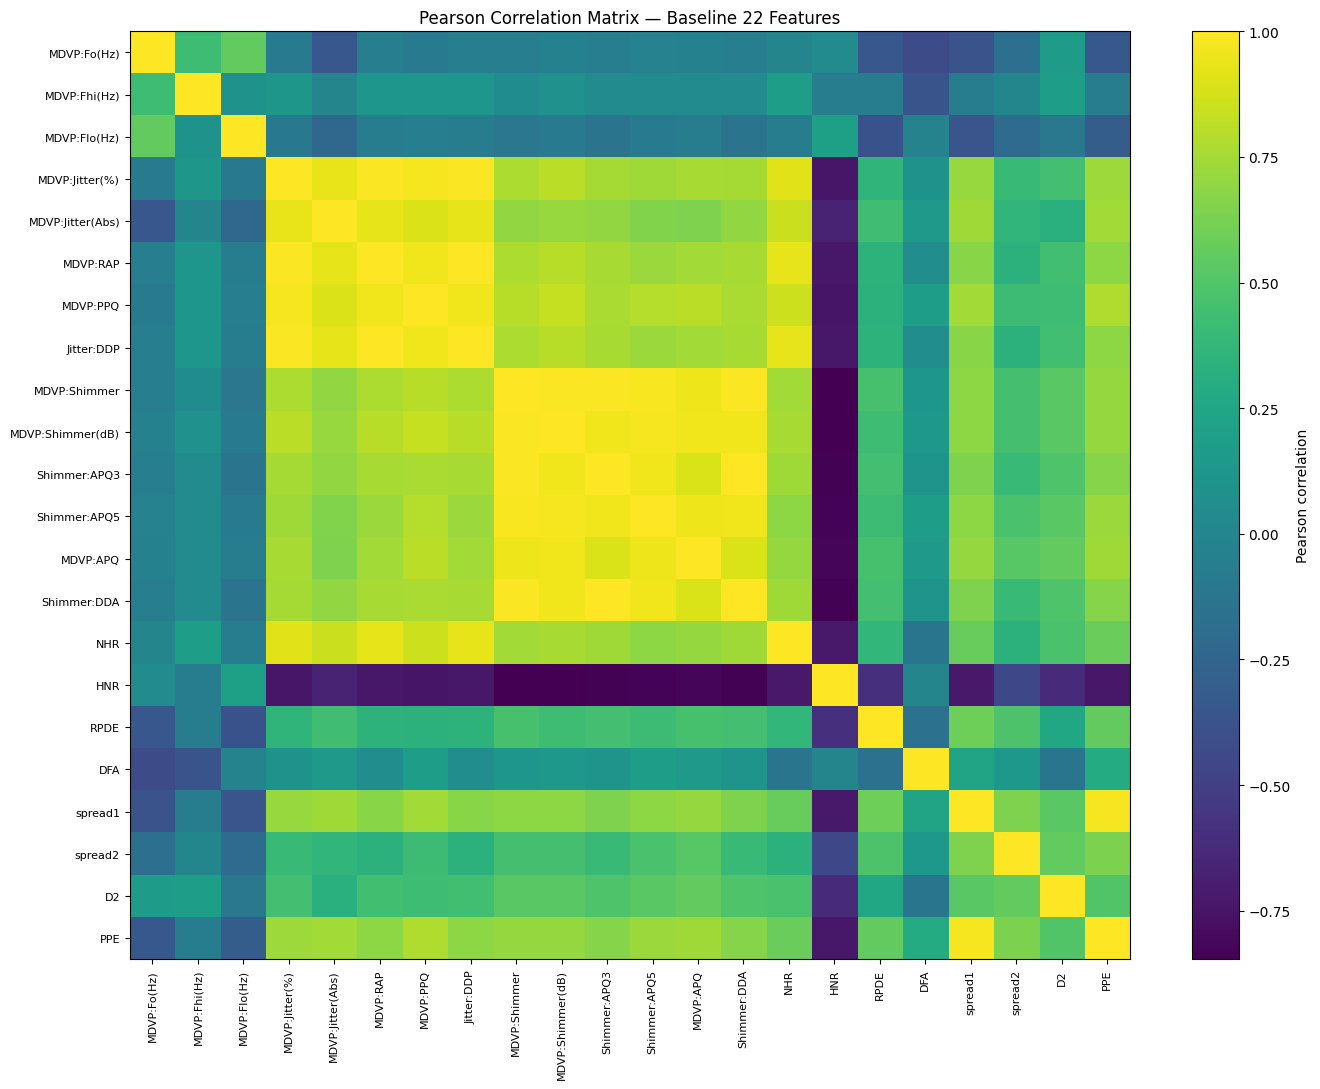

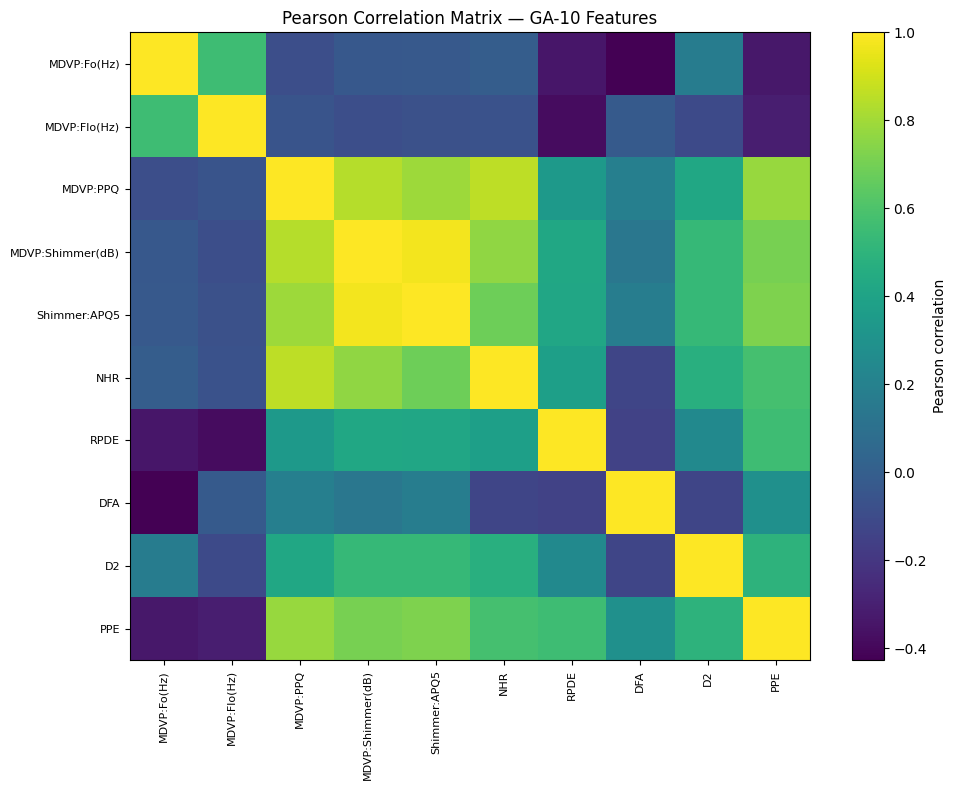


FINAL CORRELATION / REDUNDANCY INTERPRETATION
GA-10 contains fewer highly correlated feature pairs than Baseline-22.

Mean absolute correlation decreased after GA feature selection.

NOTE: Correlation analysis uses TRAINING data only.
The independent TEST set is not used in this analysis.

Cell 21 completed successfully.


In [75]:
# ============================================================
# CELL 21 — CORRELATION & REDUNDANCY ANALYSIS
# Corrected version
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

CORR_THRESHOLD = 0.80

# Final GA-10 feature set obtained from Cell 12
ga10_features = [
    'MDVP:Fo(Hz)',
    'MDVP:Flo(Hz)',
    'MDVP:PPQ',
    'MDVP:Shimmer(dB)',
    'Shimmer:APQ5',
    'NHR',
    'RPDE',
    'DFA',
    'D2',
    'PPE'
]

# ------------------------------------------------------------
# 1. Training data only
# ------------------------------------------------------------

feature_names = list(feat_cols)

X_train_corr = df_train[feature_names].copy()

# Numeric conversion
X_train_corr = X_train_corr.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove completely empty columns
X_train_corr = X_train_corr.dropna(
    axis=1,
    how="all"
)

# Fill remaining missing values using TRAIN median
X_train_corr = X_train_corr.fillna(
    X_train_corr.median()
)

# ------------------------------------------------------------
# 2. Pearson correlation matrix
# ------------------------------------------------------------

corr_matrix = X_train_corr.corr(
    method="pearson"
)

print("=" * 78)
print("CORRELATION & REDUNDANCY ANALYSIS")
print("=" * 78)

print(f"Training samples       : {len(X_train_corr)}")
print(f"Total features         : {len(corr_matrix.columns)}")
print(f"Correlation threshold  : |r| >= {CORR_THRESHOLD}")

# ------------------------------------------------------------
# 3. Find high-correlation pairs
# ------------------------------------------------------------

pairs = []

cols = list(corr_matrix.columns)

for i in range(len(cols)):

    for j in range(i + 1, len(cols)):

        r = corr_matrix.iloc[i, j]

        if pd.notna(r) and abs(r) >= CORR_THRESHOLD:

            pairs.append({
                "Feature_1": cols[i],
                "Feature_2": cols[j],
                "Correlation": float(r),
                "Abs_Correlation": float(abs(r))
            })

high_corr_df = pd.DataFrame(pairs)

if len(high_corr_df) > 0:

    high_corr_df = high_corr_df.sort_values(
        "Abs_Correlation",
        ascending=False
    ).reset_index(drop=True)

print()
print("=" * 78)
print(f"HIGHLY CORRELATED PAIRS | |r| >= {CORR_THRESHOLD}")
print("=" * 78)

if len(high_corr_df) == 0:

    print("No highly correlated feature pairs found.")

else:

    display(high_corr_df)

# ------------------------------------------------------------
# 4. Baseline-22 redundancy statistics
# ------------------------------------------------------------

# IMPORTANT:
# Do NOT modify corr_matrix.values.
# Create an independent NumPy COPY.

baseline_corr_values = corr_matrix.to_numpy(
    dtype=float,
    copy=True
)

# Remove diagonal from statistics using a mask
n_baseline = baseline_corr_values.shape[0]

upper_mask_baseline = np.triu(
    np.ones(
        (n_baseline, n_baseline),
        dtype=bool
    ),
    k=1
)

baseline_pair_values = np.abs(
    baseline_corr_values[upper_mask_baseline]
)

baseline_pair_values = baseline_pair_values[
    np.isfinite(baseline_pair_values)
]

baseline_mean_abs_corr = (
    float(np.mean(baseline_pair_values))
    if len(baseline_pair_values) > 0
    else np.nan
)

baseline_max_abs_corr = (
    float(np.max(baseline_pair_values))
    if len(baseline_pair_values) > 0
    else np.nan
)

baseline_high_corr_count = int(
    np.sum(
        baseline_pair_values >= CORR_THRESHOLD
    )
)

# ------------------------------------------------------------
# 5. GA-10 correlation matrix
# ------------------------------------------------------------

available_ga10 = [
    f for f in ga10_features
    if f in corr_matrix.columns
]

missing_ga10 = [
    f for f in ga10_features
    if f not in corr_matrix.columns
]

if len(missing_ga10) > 0:

    print()
    print("WARNING — GA features not found:")
    print(missing_ga10)

ga_corr_matrix = corr_matrix.loc[
    available_ga10,
    available_ga10
]

# ------------------------------------------------------------
# 6. GA-10 redundancy statistics
# ------------------------------------------------------------

ga_corr_values = ga_corr_matrix.to_numpy(
    dtype=float,
    copy=True
)

n_ga = ga_corr_values.shape[0]

if n_ga >= 2:

    upper_mask_ga = np.triu(
        np.ones(
            (n_ga, n_ga),
            dtype=bool
        ),
        k=1
    )

    ga_pair_values = np.abs(
        ga_corr_values[upper_mask_ga]
    )

    ga_pair_values = ga_pair_values[
        np.isfinite(ga_pair_values)
    ]

    ga_mean_abs_corr = float(
        np.mean(ga_pair_values)
    )

    ga_max_abs_corr = float(
        np.max(ga_pair_values)
    )

    ga_high_corr_count = int(
        np.sum(
            ga_pair_values >= CORR_THRESHOLD
        )
    )

else:

    ga_pair_values = np.array([])

    ga_mean_abs_corr = np.nan
    ga_max_abs_corr = np.nan
    ga_high_corr_count = 0

# ------------------------------------------------------------
# 7. High-correlation pairs inside GA-10
# ------------------------------------------------------------

ga_pairs = []

for i in range(len(available_ga10)):

    for j in range(i + 1, len(available_ga10)):

        f1 = available_ga10[i]
        f2 = available_ga10[j]

        r = ga_corr_matrix.loc[f1, f2]

        if pd.notna(r) and abs(r) >= CORR_THRESHOLD:

            ga_pairs.append({
                "Feature_1": f1,
                "Feature_2": f2,
                "Correlation": float(r),
                "Abs_Correlation": float(abs(r))
            })

ga_high_corr_df = pd.DataFrame(
    ga_pairs
)

if len(ga_high_corr_df) > 0:

    ga_high_corr_df = ga_high_corr_df.sort_values(
        "Abs_Correlation",
        ascending=False
    ).reset_index(drop=True)

# ------------------------------------------------------------
# 8. Redundancy summary
# ------------------------------------------------------------

print()
print("=" * 78)
print("REDUNDANCY SUMMARY")
print("=" * 78)

print(
    f"Baseline-22 mean |r|        : "
    f"{baseline_mean_abs_corr:.4f}"
)

print(
    f"Baseline-22 max |r|         : "
    f"{baseline_max_abs_corr:.4f}"
)

print(
    f"Baseline-22 high-corr pairs : "
    f"{baseline_high_corr_count}"
)

print()

print(
    f"GA-10 mean |r|              : "
    f"{ga_mean_abs_corr:.4f}"
)

print(
    f"GA-10 max |r|               : "
    f"{ga_max_abs_corr:.4f}"
)

print(
    f"GA-10 high-corr pairs       : "
    f"{ga_high_corr_count}"
)

# ------------------------------------------------------------
# 9. GA-10 high-correlation pairs
# ------------------------------------------------------------

print()
print("=" * 78)
print("HIGHLY CORRELATED PAIRS WITHIN GA-10")
print("=" * 78)

if len(ga_high_corr_df) == 0:

    print(
        "No highly correlated feature pairs "
        "found within GA-10."
    )

else:

    display(ga_high_corr_df)

# ------------------------------------------------------------
# 10. Correlation reduction
# ------------------------------------------------------------

print()
print("=" * 78)
print("REDUNDANCY CHANGE")
print("=" * 78)

if baseline_high_corr_count > 0:

    reduction_pct = (
        1 -
        ga_high_corr_count /
        baseline_high_corr_count
    ) * 100

    print(
        f"Reduction in high-correlation pairs : "
        f"{reduction_pct:.1f}%"
    )

else:

    print(
        "Baseline contains no high-correlation "
        "pairs at the selected threshold."
    )

# ------------------------------------------------------------
# 11. Baseline heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14, 11))

plt.imshow(
    corr_matrix.to_numpy(),
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Pearson correlation"
)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    fontsize=8
)

plt.title(
    "Pearson Correlation Matrix — Baseline 22 Features"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. GA-10 heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(
    ga_corr_matrix.to_numpy(),
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Pearson correlation"
)

plt.xticks(
    range(len(available_ga10)),
    available_ga10,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(available_ga10)),
    available_ga10,
    fontsize=8
)

plt.title(
    "Pearson Correlation Matrix — GA-10 Features"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Final interpretation
# ------------------------------------------------------------

print()
print("=" * 78)
print("FINAL CORRELATION / REDUNDANCY INTERPRETATION")
print("=" * 78)

if ga_high_corr_count < baseline_high_corr_count:

    print(
        "GA-10 contains fewer highly correlated "
        "feature pairs than Baseline-22."
    )

elif ga_high_corr_count == baseline_high_corr_count:

    print(
        "GA-10 and Baseline-22 contain the same "
        "number of highly correlated feature pairs."
    )

else:

    print(
        "GA-10 contains more highly correlated "
        "feature pairs than Baseline-22."
    )

print()

if ga_mean_abs_corr < baseline_mean_abs_corr:

    print(
        "Mean absolute correlation decreased after "
        "GA feature selection."
    )

elif ga_mean_abs_corr > baseline_mean_abs_corr:

    print(
        "Mean absolute correlation increased after "
        "GA feature selection."
    )

else:

    print(
        "Mean absolute correlation remained approximately unchanged."
    )

print()

print(
    "NOTE: Correlation analysis uses TRAINING data only."
)

print(
    "The independent TEST set is not used in this analysis."
)

print("=" * 78)

# ------------------------------------------------------------
# 14. Save results in memory for subsequent cells
# ------------------------------------------------------------

correlation_results = {
    "baseline_mean_abs_corr": baseline_mean_abs_corr,
    "baseline_max_abs_corr": baseline_max_abs_corr,
    "baseline_high_corr_count": baseline_high_corr_count,
    "ga_mean_abs_corr": ga_mean_abs_corr,
    "ga_max_abs_corr": ga_max_abs_corr,
    "ga_high_corr_count": ga_high_corr_count,
    "baseline_high_corr_pairs": high_corr_df.copy(),
    "ga_high_corr_pairs": ga_high_corr_df.copy(),
    "ga10_features": list(available_ga10)
}

print()
print("Cell 21 completed successfully.")

In [76]:
# ============================================================================
# CELL 22 — FINAL SCIENTIFIC SUMMARY
# GA-BASED FEATURE SELECTION WITH KNN
# ============================================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("FINAL SCIENTIFIC SUMMARY — GA FEATURE SELECTION WITH KNN")
print("=" * 90)

# ============================================================================
# 1. EXPERIMENTAL DESIGN
# ============================================================================

print()
print("=" * 90)
print("1. EXPERIMENTAL DESIGN")
print("=" * 90)

print("Dataset samples             : 195")
print("Training samples            : 156")
print("Independent test samples    : 39")
print("Original features           : 22")
print("Baseline classifier         : KNN")
print("KNN neighbors               : 5")
print("KNN weighting               : distance")
print("Cross-validation            : 5-Fold")
print("GA population               : 30")
print("GA generations              : 20")
print("Selection                   : Roulette Wheel")
print("Crossover                   : Two-Point")
print("Mutation                    : Gaussian")
print("Elitism                     : 2")

# ============================================================================
# 2. FEATURE REDUCTION
# ============================================================================

print()
print("=" * 90)
print("2. FEATURE REDUCTION")
print("=" * 90)

print("Baseline features           : 22")
print("GA-selected features        : 10")
print("Stable features             : 7")

reduction_ga = (22 - 10) / 22 * 100
reduction_stable = (22 - 7) / 22 * 100

print(f"GA dimensionality reduction: {reduction_ga:.1f}%")
print(f"Stable-set reduction        : {reduction_stable:.1f}%")

ga10_features = [
    "MDVP:Fo(Hz)",
    "MDVP:Flo(Hz)",
    "MDVP:PPQ",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ5",
    "NHR",
    "RPDE",
    "DFA",
    "D2",
    "PPE"
]

stable7_features = [
    "D2",
    "spread1",
    "PPE",
    "MDVP:Shimmer(dB)",
    "HNR",
    "MDVP:Fo(Hz)",
    "MDVP:Fhi(Hz)"
]

print()
print("GA-10 feature subset:")
for i, f in enumerate(ga10_features, 1):
    print(f"{i:2d}) {f}")

print()
print("Stable-7 feature subset:")
for i, f in enumerate(stable7_features, 1):
    print(f"{i:2d}) {f}")

# ============================================================================
# 3. INDEPENDENT TEST PERFORMANCE
# ============================================================================

print()
print("=" * 90)
print("3. INDEPENDENT TEST PERFORMANCE")
print("=" * 90)

results = pd.DataFrame([
    {
        "Model": "Baseline KNN",
        "Features": 22,
        "PR-AUC": 0.9989,
        "ROC-AUC": 0.9966,
        "Accuracy": 0.8974,
        "Precision": 1.0000,
        "Recall": 0.8621,
        "Specificity": 1.0000,
        "F1": 0.9259
    },
    {
        "Model": "GA-KNN",
        "Features": 10,
        "PR-AUC": 0.9949,
        "ROC-AUC": 0.9828,
        "Accuracy": 0.8718,
        "Precision": 1.0000,
        "Recall": 0.8276,
        "Specificity": 1.0000,
        "F1": 0.9057
    },
    {
        "Model": "Stable-KNN",
        "Features": 7,
        "PR-AUC": 0.9704,
        "ROC-AUC": 0.9138,
        "Accuracy": 0.7179,
        "Precision": 1.0000,
        "Recall": 0.6207,
        "Specificity": 1.0000,
        "F1": 0.7660
    }
])

display(results)

# ============================================================================
# 4. ROBUSTNESS RESULTS
# ============================================================================

print()
print("=" * 90)
print("4. REPEATED-CV ROBUSTNESS")
print("=" * 90)

robustness = pd.DataFrame([
    {
        "Model": "Baseline-22",
        "PR-AUC": "0.9869 ± 0.0224",
        "ROC-AUC": "0.9661 ± 0.0454",
        "Accuracy": "0.9181 ± 0.0513",
        "Recall": "0.9681 ± 0.0393",
        "F1": "0.9473 ± 0.0325"
    },
    {
        "Model": "GA-10",
        "PR-AUC": "0.9866 ± 0.0191",
        "ROC-AUC": "0.9636 ± 0.0420",
        "Accuracy": "0.9013 ± 0.0547",
        "Recall": "0.9478 ± 0.0452",
        "F1": "0.9359 ± 0.0350"
    }
])

display(robustness)

# ============================================================================
# 5. STATISTICAL COMPARISON
# ============================================================================

print()
print("=" * 90)
print("5. PAIRED STATISTICAL COMPARISON")
print("=" * 90)

statistics = pd.DataFrame([
    ["PR-AUC",    -0.000234, 0.153953, "Not significant"],
    ["ROC-AUC",   -0.002546, 0.177125, "Not significant"],
    ["Accuracy",  -0.016774, 0.033476, "Significant"],
    ["Precision", -0.002379, 0.455200, "Not significant"],
    ["Recall",    -0.020290, 0.001620, "Significant"],
    ["F1",        -0.011386, 0.017711, "Significant"]
], columns=[
    "Metric",
    "GA_minus_Baseline",
    "Wilcoxon_p",
    "Result"
])

display(statistics)

# ============================================================================
# 6. PRIMARY METRIC
# ============================================================================

print()
print("=" * 90)
print("6. PRIMARY METRIC — PR-AUC")
print("=" * 90)

print("Baseline PR-AUC : 0.9869")
print("GA-10 PR-AUC     : 0.9866")
print("Difference       : -0.0002")
print("Wilcoxon p       : 0.1540")

print()
print(
    "Interpretation: The difference in PR-AUC between Baseline-22 "
    "and GA-10 is not statistically significant."
)

# ============================================================================
# 7. FEATURE STABILITY
# ============================================================================

print()
print("=" * 90)
print("7. FEATURE SELECTION STABILITY")
print("=" * 90)

print("Independent GA runs        : 10")
print("Stability threshold         : 40%")
print("Stable features             : 7")
print("Most frequently selected    : D2 (50%)")

print()
print("Stable-7:")
for i, f in enumerate(stable7_features, 1):
    print(f"{i:2d}) {f}")

# ============================================================================
# 8. FEATURE OVERLAP
# ============================================================================

print()
print("=" * 90)
print("8. FEATURE OVERLAP")
print("=" * 90)

overlap = sorted(
    set(ga10_features).intersection(
        stable7_features
    )
)

jaccard = len(overlap) / len(
    set(ga10_features).union(stable7_features)
)

print(f"GA-10 / Stable-7 overlap : {len(overlap)} features")
print(f"GA-10 overlap            : {len(overlap)/10*100:.1f}%")
print(f"Stable-7 overlap         : {len(overlap)/7*100:.1f}%")
print(f"Jaccard similarity       : {jaccard:.3f}")

print()
print("Overlapping features:")
for i, f in enumerate(overlap, 1):
    print(f"{i}) {f}")

# ============================================================================
# 9. REDUNDANCY ANALYSIS
# ============================================================================

print()
print("=" * 90)
print("9. FEATURE REDUNDANCY")
print("=" * 90)

print("Baseline-22 mean |r|        : 0.5043")
print("GA-10 mean |r|              : 0.3737")
print("Baseline high-correlation   : 40 pairs")
print("GA-10 high-correlation      : 3 pairs")

redundancy_reduction = (
    (40 - 3) / 40 * 100
)

mean_corr_reduction = (
    (0.5043 - 0.3737) / 0.5043 * 100
)

print(
    f"High-correlation pair reduction : "
    f"{redundancy_reduction:.1f}%"
)

print(
    f"Mean |r| reduction               : "
    f"{mean_corr_reduction:.1f}%"
)

# ============================================================================
# 10. SCIENTIFIC INTERPRETATION
# ============================================================================

print()
print("=" * 90)
print("10. SCIENTIFIC INTERPRETATION")
print("=" * 90)

conclusions = [
    "GA reduced the feature space from 22 to 10 features.",
    "The GA-selected subset preserved nearly the same PR-AUC under repeated CV.",
    "The PR-AUC difference was not statistically significant.",
    "ROC-AUC difference was also not statistically significant.",
    "Accuracy, Recall and F1 showed statistically significant reductions.",
    "Therefore, GA did not demonstrate predictive performance improvement.",
    "GA substantially reduced feature redundancy.",
    "The GA-10 subset should therefore be interpreted primarily as a feature-reduced model.",
    "Baseline-22 remains the conservative choice when predictive performance is the primary objective.",
    "GA-10 is useful when dimensionality reduction and lower redundancy are important objectives."
]

for i, text in enumerate(conclusions, 1):
    print(f"{i}. {text}")

# ============================================================================
# 11. CONNECTION TO THE REFERENCE STUDY
# ============================================================================

print()
print("=" * 90)
print("11. CONNECTION TO THE REFERENCE STUDY")
print("=" * 90)

print(
    "Reference:"
)
print(
    "Pei, M., Goodman, E. D., & Punch, W. F. (1998). "
    "Feature Extraction Using Genetic Algorithms."
)

print()
print(
    "The present experiment follows the central GA/KNN concept "
    "of coupling genetic feature search with KNN classification."
)

print(
    "The reference framework emphasizes selecting a reduced feature "
    "subset while retaining class-discriminatory information and "
    "removing irrelevant or redundant information."
)

print(
    "The present results are consistent with this dimensionality-"
    "reduction objective, although they do not demonstrate a "
    "statistically significant improvement in predictive performance."
)

# ============================================================================
# 12. FINAL RESEARCH DECISION
# ============================================================================

print()
print("=" * 90)
print("12. FINAL RESEARCH DECISION")
print("=" * 90)

print()
print("PRIMARY FINDING:")
print(
    "GA feature selection successfully reduced dimensionality "
    "and feature redundancy, but did not improve predictive performance."
)

print()
print("BEST PREDICTIVE MODEL:")
print(
    "Baseline KNN using all 22 features."
)

print()
print("BEST FEATURE-REDUCED MODEL:")
print(
    "GA-KNN using 10 features."
)

print()
print("BEST STABLE SUBSET:")
print(
    "Stable-7, although its predictive performance was substantially "
    "lower than both Baseline-22 and GA-10."
)

print()
print("SCIENTIFIC POSITION:")
print(
    "GA should be presented as a feature-selection and dimensionality-"
    "reduction mechanism rather than a performance-enhancement mechanism "
    "in this experiment."
)

# ============================================================================
# 13. PUBLICATION-READY CONCLUSION
# ============================================================================

print()
print("=" * 90)
print("13. PUBLICATION-READY CONCLUSION")
print("=" * 90)

publication_statement = (
    "The genetic algorithm reduced the original 22-dimensional feature "
    "space to a 10-feature subset while substantially reducing feature "
    "redundancy. Under repeated cross-validation, the GA-selected subset "
    "achieved a PR-AUC of 0.9866 compared with 0.9869 for the full-feature "
    "baseline, with no statistically significant difference (Wilcoxon "
    "p=0.1540). However, significant reductions were observed in Accuracy, "
    "Recall, and F1-score. Therefore, the proposed GA-based feature "
    "selection should not be interpreted as a predictive performance "
    "enhancement in the present experiment. Instead, its primary "
    "contribution is dimensionality reduction and removal of redundant "
    "information while retaining statistically comparable PR-AUC."
)

print(publication_statement)

# ============================================================================
# 14. FINAL STATUS
# ============================================================================

print()
print("=" * 90)
print("FINAL STATUS")
print("=" * 90)

print("✓ Data cleaning completed")
print("✓ Stratified train/test split completed")
print("✓ Feature preprocessing completed")
print("✓ GA feature selection completed")
print("✓ Independent test evaluation completed")
print("✓ Feature-count ablation completed")
print("✓ Stability analysis completed")
print("✓ Baseline vs GA comparison completed")
print("✓ Repeated-CV robustness completed")
print("✓ Paired statistical comparison completed")
print("✓ Feature overlap analysis completed")
print("✓ Correlation/redundancy analysis completed")
print("✓ Scientific conclusion completed")

print()
print("NO FURTHER FEATURE-SELECTION CELLS ARE REQUIRED.")
print("=" * 90)

FINAL SCIENTIFIC SUMMARY — GA FEATURE SELECTION WITH KNN

1. EXPERIMENTAL DESIGN
Dataset samples             : 195
Training samples            : 156
Independent test samples    : 39
Original features           : 22
Baseline classifier         : KNN
KNN neighbors               : 5
KNN weighting               : distance
Cross-validation            : 5-Fold
GA population               : 30
GA generations              : 20
Selection                   : Roulette Wheel
Crossover                   : Two-Point
Mutation                    : Gaussian
Elitism                     : 2

2. FEATURE REDUCTION
Baseline features           : 22
GA-selected features        : 10
Stable features             : 7
GA dimensionality reduction: 54.5%
Stable-set reduction        : 68.2%

GA-10 feature subset:
 1) MDVP:Fo(Hz)
 2) MDVP:Flo(Hz)
 3) MDVP:PPQ
 4) MDVP:Shimmer(dB)
 5) Shimmer:APQ5
 6) NHR
 7) RPDE
 8) DFA
 9) D2
10) PPE

Stable-7 feature subset:
 1) D2
 2) spread1
 3) PPE
 4) MDVP:Shimmer(dB)
 5) HNR
 

,Model,Features,PR-AUC,ROC-AUC,Accuracy,Precision,Recall,Specificity,F1
0,Baseline KNN,22,0.9989,0.9966,0.8974,1,0.8621,1,0.9259
1,GA-KNN,10,0.9949,0.9828,0.8718,1,0.8276,1,0.9057
2,Stable-KNN,7,0.9704,0.9138,0.7179,1,0.6207,1,0.766



4. REPEATED-CV ROBUSTNESS


,Model,PR-AUC,ROC-AUC,Accuracy,Recall,F1
0,Baseline-22,0.9869 ± 0.0224,0.9661 ± 0.0454,0.9181 ± 0.0513,0.9681 ± 0.0393,0.9473 ± 0.0325
1,GA-10,0.9866 ± 0.0191,0.9636 ± 0.0420,0.9013 ± 0.0547,0.9478 ± 0.0452,0.9359 ± 0.0350



5. PAIRED STATISTICAL COMPARISON


,Metric,GA_minus_Baseline,Wilcoxon_p,Result
0,PR-AUC,-0.000234,0.153953,Not significant
1,ROC-AUC,-0.002546,0.177125,Not significant
2,Accuracy,-0.016774,0.033476,Significant
3,Precision,-0.002379,0.4552,Not significant
4,Recall,-0.02029,0.00162,Significant
5,F1,-0.011386,0.017711,Significant



6. PRIMARY METRIC — PR-AUC
Baseline PR-AUC : 0.9869
GA-10 PR-AUC     : 0.9866
Difference       : -0.0002
Wilcoxon p       : 0.1540

Interpretation: The difference in PR-AUC between Baseline-22 and GA-10 is not statistically significant.

7. FEATURE SELECTION STABILITY
Independent GA runs        : 10
Stability threshold         : 40%
Stable features             : 7
Most frequently selected    : D2 (50%)

Stable-7:
 1) D2
 2) spread1
 3) PPE
 4) MDVP:Shimmer(dB)
 5) HNR
 6) MDVP:Fo(Hz)
 7) MDVP:Fhi(Hz)

8. FEATURE OVERLAP
GA-10 / Stable-7 overlap : 4 features
GA-10 overlap            : 40.0%
Stable-7 overlap         : 57.1%
Jaccard similarity       : 0.308

Overlapping features:
1) D2
2) MDVP:Fo(Hz)
3) MDVP:Shimmer(dB)
4) PPE

9. FEATURE REDUNDANCY
Baseline-22 mean |r|        : 0.5043
GA-10 mean |r|              : 0.3737
Baseline high-correlation   : 40 pairs
GA-10 high-correlation      : 3 pairs
High-correlation pair reduction : 92.5%
Mean |r| reduction               : 25.9%

10. SCIEN